# TP1 · Task 1: Understand, audit and prepare the data
## Classification of abnormal electric-vehicle charging sessions

**Course:** Mineração de Dados (MINDD), 2026/2027, 1st semester, ISEP / DEI

**Dataset:** educational version of the *China EV Charging Dataset* (Zhang et al., 2025). It has 441,077 charging sessions,
92 charging posts, 13 stations and 3 districts, from 2020 to 2021.

### How to read this notebook

The project asks: *to what extent can contextual, operational and historical information available at the beginning of a
charging session be used to predict that the session will end abnormally?*

While working on this task we tried to follow three rules. First, a column can only be used as a predictor if its value is
known when the session starts. Things recorded during or after the session (energy delivered, cost, end time, end cause)
describe the result, and the slides call them *false predictors* or "leakers". Second, before removing, imputing, capping or
grouping anything, we first try to understand what is going on. Third, anything that learns values from the data
(imputation values, scaling, encoding, thresholds, resampling, feature selection) is fitted on the training period only,
which is what the slides call *preventing data leakage*.

Each decision we take is also written to a small decision log, shown at the end. The table below links our sections to the
topics of the Data Preparation slides.

| # | Section | Topic in the Data Preparation slides |
|---|---------|---------------------------------------|
| 1 | Setup | — |
| 2 | Load and first look | Understanding the data |
| 3 | Variables and when they are known | Feature reduction: key fields and leakers |
| 4 | Cleaning and consistency checks | Data cleaning: inconsistencies |
| 5 | The target `is_Abnormal` | — |
| 6 | Missing values | Data cleaning: missing values |
| 7 | Changes over time | Understanding the data, data selection |
| 8 | Leakage and availability at the start | Feature reduction: leakers |
| 9 | Exploring the start-time predictors | Understanding the data |
| 10 | Outliers | Outliers |
| 11 | Data selection: time split and sampling | Data selection, sampling |
| 12 | Feature engineering and reduction | Transformation, correlation, VIF, PCA, discretisation |
| 13 | Learned operations and class imbalance | Encoding, scaling, log transform, unbalanced classes |
| 14 | Saved files and integrity checks | — |
| 15 | Synthesis | — |

---
## 1. Setup

The paths are relative, so the notebook has to be run from the folder that contains `Charging_Data_educational.csv`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

SEED = 42
DATA_PATH = Path("Charging_Data_educational.csv")
OUT_DIR = Path("prepared")
FIG_DIR = OUT_DIR / "figures_merged"    # figures of this notebook
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET = "is_Abnormal"

# Time periods. They are justified in Sections 7 and 11 but defined once here.
BURN_IN_END = pd.Timestamp("2020-04-01")   # sessions before this date are not used for modelling
TRAIN_END = pd.Timestamp("2021-07-01")     # train:      2020-04-01 to 2021-06-30
VAL_END = pd.Timestamp("2021-10-01")       # validation: 2021-07-01 to 2021-09-30; test: 2021-10-01 to the end

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 200)
C_NORMAL, C_ABN, C_GREY = "#4C72B0", "#C44E52", "#7F7F7F"

DECISIONS = []


def log_decision(section, topic, decision, evidence):
    """Store a preparation decision together with its evidence (the full log is shown in Section 15)."""
    DECISIONS.append({"section": section, "topic": topic, "decision": decision, "evidence": evidence})


def savefig(fig, name):
    """Save a figure for the report and show it."""
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)
    plt.show()


def abnormal_rate(frame, by):
    """Number of sessions and share of abnormal sessions per group."""
    return frame.groupby(by, observed=True)[TARGET].agg(sessions="size", abnormal_rate="mean")


def auc(y, x):
    """Univariate ROC-AUC without direction: 0.5 = no signal, 1.0 = perfect separation of the two classes."""
    a = roc_auc_score(y, x)
    return max(a, 1 - a)

---
## 2. Load and first look

We start by loading the file and looking at a few rows, the column types and whether the raw text is clean.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Sessions (rows): {len(raw):,} | columns: {raw.shape[1]}")
display(raw.head(3).T)

Sessions (rows): 441,077 | columns: 47


,0,1,2
UserID,11182,27510,10877
Charging Post ID,24,67,45
Location Information,Shopping Mall,Government Agency,Park B
District Name,Tongxiang,Xiuzhou,Tongxiang
Order creation time,2019-12-31 21:26:58\t,2019-12-31 21:50:58\t,2019-12-31 22:19:34\t
Transaction power/kwh,37.65,12.03,44.04
Electricity cost/Yuan,33.62,10.74,39.33
Service charge/Yuan,26.62,8.51,31.14
Transaction Amount/Yuan,60.24,19.25,70.47
Actual Payment/Yuan,60.24,19.25,70.47


In [3]:
overview = pd.DataFrame({
    "type": raw.dtypes.astype(str),
    "unique values": raw.nunique(),
    "missing": raw.isna().sum(),
})
display(overview)

,type,unique values,missing
UserID,int64,56115,0
Charging Post ID,int64,92,0
Location Information,str,13,0
District Name,str,3,0
Order creation time,str,438764,0
Transaction power/kwh,float64,7053,0
Electricity cost/Yuan,float64,6320,0
Service charge/Yuan,float64,5129,0
Transaction Amount/Yuan,float64,8487,0
Actual Payment/Yuan,float64,8412,0


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
UserID,441077.0,13262.864430,14286.825468,1.000000,2478.000000,8819.000000,19614.000000,56117.000000
Charging Post ID,441077.0,48.829583,25.045206,1.000000,26.000000,51.000000,69.000000,92.000000
Transaction power/kwh,441077.0,16.436574,13.253881,0.000000,5.440000,15.150000,24.740000,117.740000
Electricity cost/Yuan,441077.0,12.158460,10.830214,0.000000,3.340000,10.110000,18.160000,121.160000
Service charge/Yuan,441077.0,7.450791,8.152830,0.000000,1.070000,5.100000,10.990000,101.260000
Transaction Amount/Yuan,441077.0,19.609251,15.958935,0.000000,6.270000,18.440000,29.700000,147.170000
Actual Payment/Yuan,441077.0,18.487883,15.924672,0.000000,4.600000,16.650000,29.370000,147.170000
Temperature(℃),441077.0,19.708336,8.481954,-3.200000,12.700000,21.000000,26.900000,33.600000
Relative Humidity(%),441077.0,75.030351,12.656150,32.000000,67.000000,76.000000,84.000000,99.000000
Precipitation(mm),441077.0,3.510698,10.833238,0.000000,0.000000,0.000000,1.200000,152.100000


In [5]:
# We check for hidden spaces/tabs because they create duplicate categories ("Park" vs "Park\t") and break date parsing
text_cols = raw.select_dtypes(include=["object", "string"]).columns
whitespace = pd.DataFrame({
    "rows with extra spaces/tabs": [int((raw[c] != raw[c].str.strip()).sum()) for c in text_cols],
    "unique values (raw)": [raw[c].nunique() for c in text_cols],
    "unique values (stripped)": [raw[c].str.strip().nunique() for c in text_cols],
}, index=text_cols)
display(whitespace)

,rows with extra spaces/tabs,unique values (raw),unique values (stripped)
Location Information,18370,13,13
District Name,0,3,3
Order creation time,441077,438764,438764
Start Time,0,438689,438689
End Time,0,438679,438679
Payment time,441077,421831,421831
end_cause,0,15,15
tariff_period,0,7,7


One row is one charging session, and the file has 441,077 sessions and 47 columns. The four timestamps are read as text, so
we have to convert them to dates ourselves. Only four columns have missing values; we look at them in Section 6.

Something we did not expect is that `Order creation time` and `Payment time` end with a TAB character in every row, and
`Location Information` has one in 18,370 rows (all of them `Industrial Park`). Right now this does not create extra
categories, because each label is written in only one way. A future file that mixes both spellings would create a fake
extra category, though, so we strip the spaces and tabs from all text columns. This loses no information.

---
## 3. Variables and when they are known

The prediction is made at `Start Time`, so a column is only useful if its value already exists at that moment. Before any
analysis we grouped the 47 columns by when they become known:

| Group | Columns | Known at the start? | Note |
|-------|---------|---------------------|------|
| Identifiers | `UserID`, `Charging Post ID` | yes | key fields; `UserID` has 56,115 values (see Sections 9.5 and 12) |
| Location | `Location Information` (station), `District Name` | yes | |
| Start time | `Start Time` | yes | defines the prediction moment; we derive hour and day of week from it |
| Weather | `Temperature(℃)`, `Relative Humidity(%)`, `Precipitation(mm)` | assumed | the brief says to treat weather as a forecast available at the start |
| Tariff | `electricity_price`, `tariff_period` | yes | depend only on the start hour |
| Post history | 13 `post_*` columns | yes | built from earlier completed sessions of the same post (checked in Section 5.2) |
| User history | 13 `user_*` columns and `is_new_user` | yes, if the account is known | built from earlier completed sessions of the same account |
| Concurrency | `user_active_sessions_at_start` | yes | other sessions of the same account already running |
| Borderline | `Order creation time` | unclear | often stamped *after* the start (Section 8.2) |
| After the session | energy, the four money columns, `End Time`, `Payment time` | no | they describe the result, so they are leakers |
| Outcome | `end_cause` | no | only used to build the target (Section 5) |

In [6]:
POST_HIST = [c for c in raw.columns if c.startswith("post_")]
USER_HIST = [c for c in raw.columns if c.startswith("user_") and c != "user_active_sessions_at_start"] + ["is_new_user"]
column_groups = {
    "identifiers": ["UserID", "Charging Post ID"],
    "location": ["Location Information", "District Name"],
    "start time": ["Start Time"],
    "weather": ["Temperature(℃)", "Relative Humidity(%)", "Precipitation(mm)"],
    "tariff": ["electricity_price", "tariff_period"],
    "post history": POST_HIST,
    "user history": USER_HIST,
    "concurrency": ["user_active_sessions_at_start"],
    "borderline": ["Order creation time"],
    "after the session": ["Transaction power/kwh", "Electricity cost/Yuan", "Service charge/Yuan",
                          "Transaction Amount/Yuan", "Actual Payment/Yuan", "End Time", "Payment time"],
    "outcome": ["end_cause"],
}
assert sorted(sum(column_groups.values(), [])) == sorted(raw.columns), "every column must be in exactly one group"
display(pd.Series({g: len(c) for g, c in column_groups.items()}, name="columns").to_frame())

,columns
identifiers,2
location,2
start time,1
weather,3
tariff,2
post history,13
user history,14
concurrency,1
borderline,1
after the session,7


Counting the groups, 38 of the 47 columns (including the two identifiers) could be known at the start, and most of them (27)
describe the history of the post or of the user. Seven columns are only known after the session ends, and `end_cause` is the
outcome itself, so these eight never become predictors. `Order creation time` is less clear, so we look at it in Section 8.2
before deciding.

---
## 4. Cleaning and consistency checks

The project brief says that *potential data-quality problems must be investigated before corrective action is taken*. So in
this section we only do operations that lose nothing: we strip spaces, convert the timestamps and give the columns shorter
names. No row is removed, imputed or capped here.

In [7]:
RENAME = {
    "UserID": "user_id", "Charging Post ID": "post_id", "Location Information": "location", "District Name": "district",
    "Order creation time": "order_time", "Transaction power/kwh": "energy_kwh", "Electricity cost/Yuan": "electricity_cost",
    "Service charge/Yuan": "service_charge", "Transaction Amount/Yuan": "amount", "Actual Payment/Yuan": "actual_payment",
    "Start Time": "start_time", "End Time": "end_time", "Payment time": "payment_time",
    "Temperature(℃)": "temperature", "Relative Humidity(%)": "humidity", "Precipitation(mm)": "precipitation",
}
TIME_COLS = ["order_time", "start_time", "end_time", "payment_time"]

df = raw.copy()
df.insert(0, "row_id", np.arange(len(df)))          # link back to the original file
for c in text_cols:
    df[c] = df[c].str.strip()
df = df.rename(columns=RENAME)
for c in TIME_COLS:
    df[c] = pd.to_datetime(df[c], format="%Y-%m-%d %H:%M:%S", errors="coerce")

print("Timestamps that could not be parsed:", int(df[TIME_COLS].isna().sum().sum()))
print("File sorted by start time:", df["start_time"].is_monotonic_increasing)
print("Sessions start between", df["start_time"].min(), "and", df["start_time"].max())
log_decision("4", "Text and dates", "Strip spaces/tabs, parse the four timestamps, use short column names.",
             "TAB on 100% of order/payment times and on 18,370 location labels; all timestamps parse.")

Timestamps that could not be parsed: 0
File sorted by start time: True
Sessions start between 2019-12-31 21:27:03 and 2021-12-31 23:52:14


### 4.1 Duplicated sessions

"Duplicate" can mean different things, so we checked several levels. We looked for identical rows, for the same account on
the same post at the same second, and for two sessions starting at the same second on the same post, which should be
physically impossible.

In [8]:
duplicates = pd.Series({
    "identical rows": raw.duplicated().sum(),
    "same user + post + start time": df.duplicated(["user_id", "post_id", "start_time"]).sum(),
    "same post + start time (impossible)": df.duplicated(["post_id", "start_time"]).sum(),
    "same user + start time (different posts)": df.duplicated(["user_id", "start_time"]).sum(),
}, name="rows").to_frame()
display(duplicates)

same_second = df[df.duplicated(["user_id", "start_time"], keep=False)].sort_values(["user_id", "start_time"])
print("Accounts with two sessions starting in the same second:", same_second["user_id"].nunique())
display(same_second[["user_id", "post_id", "start_time", "end_time", "end_cause"]].head(6))

,rows
identical rows,0
same user + post + start time,0
same post + start time (impossible),0
same user + start time (different posts),17


Accounts with two sessions starting in the same second: 15


,user_id,post_id,start_time,end_time,end_cause
167535,23,4,2020-12-04 11:13:49,2020-12-04 11:30:37,BMS failure
167536,23,74,2020-12-04 11:13:49,2020-12-04 12:02:37,User stops charging
34710,39,12,2020-05-20 23:55:30,2020-05-21 03:24:28,Charging ends normally
34711,39,47,2020-05-20 23:55:30,2020-05-21 00:43:06,Charging ends normally
360955,39,27,2021-09-30 23:31:00,2021-10-01 00:52:49,Charging ends normally
360956,39,63,2021-09-30 23:31:00,2021-09-30 23:35:37,User stops charging


There are no identical rows and no impossible repetitions. The only case we found is 17 pairs where one account starts two
sessions on two different posts in the same second. This looks like fleet or operator accounts that charge several vehicles
at once, so we keep these sessions as real observations.

### 4.2 Logical consistency

Next we tested a few rules that should always hold if the data are coherent, for example that a session cannot end before it
starts.

In [9]:
# Helper columns for the checks below. They are only known after the session, so they are never predictors
df["duration_h"] = (df["end_time"] - df["start_time"]).dt.total_seconds() / 3600
df["order_lag_min"] = (df["order_time"] - df["start_time"]).dt.total_seconds() / 60     # > 0: order stamped after the start
df["payment_lag_h"] = (df["payment_time"] - df["end_time"]).dt.total_seconds() / 3600

money = ["energy_kwh", "electricity_cost", "service_charge", "amount", "actual_payment"]
nested = [("post_previous_sessions_1D", "post_previous_sessions_7D", "post_previous_sessions_30D"),
          ("user_previous_sessions_30D", "user_previous_sessions_180D", "user_previous_sessions_730D")]

consistency = pd.Series({
    "end time before start time": (df["duration_h"] < 0).sum(),
    "duration of 24 h or more": (df["duration_h"] >= 24).sum(),
    "order created after the start": (df["order_lag_min"] > 0).sum(),
    "payment recorded before the end": (df["payment_lag_h"] < 0).sum(),
    "zero energy delivered": (df["energy_kwh"] == 0).sum(),
    "negative energy or money": (df[money] < 0).any(axis=1).sum(),
    "amount ≠ electricity cost + service charge (> 0.01)":
        ((df["amount"] - df["electricity_cost"] - df["service_charge"]).abs() > 0.01).sum(),
    "actual payment ≠ amount (> 0.01)": ((df["actual_payment"] - df["amount"]).abs() > 0.01).sum(),
    "history windows not nested (e.g. 1D > 7D)":
        sum(((df[a] > df[b]) | (df[b] > df[c])).sum() for a, b, c in nested),
    "previous abnormal > previous sessions (30D)":
        ((df["post_previous_abnormal_30D"] > df["post_previous_sessions_30D"])
         | (df["user_previous_abnormal_30D"] > df["user_previous_sessions_30D"])).sum(),
}, name="sessions").to_frame()
display(consistency)
print(f"Longest session: {df['duration_h'].max():.2f} h | "
      f"order stamped after the start in {(df['order_lag_min'] > 0).mean():.1%} of sessions")

,sessions
end time before start time,0
duration of 24 h or more,0
order created after the start,248588
payment recorded before the end,87202
zero energy delivered,54621
negative energy or money,0
amount ≠ electricity cost + service charge (> 0.01),0
actual payment ≠ amount (> 0.01),45812
history windows not nested (e.g. 1D > 7D),0
previous abnormal > previous sessions (30D),0


Longest session: 23.99 h | order stamped after the start in 56.4% of sessions


The basic rules hold. No session ends before it starts, no amount is negative, the total amount is always the electricity
cost plus the service charge, and the history windows are nested as expected (1 day ≤ 7 days ≤ 30 days).

A few results needed more thought. The longest session lasts 23.99 h, so the sessions seem to be cut off at 24 h. 54,621
sessions delivered zero energy, but most of them are abnormal (Section 5.3), so we think they are failed starts rather than
errors. `Order creation time` is stamped after the start in 248,588 sessions (56%), which makes it doubtful as a predictor
(Section 8.2). We also found 87,202 sessions where the payment is recorded before the end, and 45,812 where the paid amount
differs from the total (maybe discounts or coupons). We could not explain these timing and payment fields.

None of this needs fixing for our model, because duration, energy and payment are only known after the session. So we do not
remove any row.

### 4.3 Structure of location, weather and tariff

Here we checked how location, weather and tariff are organised, because this affects how we can use them later.

In [10]:
print("Maximum number of stations per post:", df.groupby("post_id")["location"].nunique().max())
print("Maximum number of districts per station:", df.groupby("location")["district"].nunique().max())
display(df.groupby(["district", "location"]).agg(posts=("post_id", "nunique"), sessions=("row_id", "size")))

for c in ["temperature", "humidity", "precipitation"]:
    per_day = df.groupby(["district", df["start_time"].dt.date])[c].nunique().max()
    print(f"Different '{c}' values within one district and day: {per_day}")

print("electricity_price values:", sorted(df["electricity_price"].unique()),
      "| different prices per tariff period:", df.groupby("tariff_period")["electricity_price"].nunique().max())

Maximum number of stations per post: 1
Maximum number of districts per station: 1


posts  sessions
district  location                                      
Nanhu     Financial Industrial Park          8     18923
          Technology Park                    4     28867
          Tourist Attraction                 8     23659
Tongxiang Bus Station                        8     60809
          Industrial Park                    8     18370
          Park A                             8     27845
          Park B                             8     57294
          Shopping Mall                      8     56605
Xiuzhou   Expressway Service District A      4     15075
          Expressway Service District B      4     12401
          Expressway Service District C      8     50187
          Government Agency                  8     36551
          Wholesale Market                   8     34491

Different 'temperature' values within one district and day: 1


Different 'humidity' values within one district and day: 1
Different 'precipitation' values within one district and day: 1
electricity_price values: [np.float64(0.3784), np.float64(0.9014), np.float64(1.2064)] | different prices per tariff period: 1


Location is a clean hierarchy: each of the 92 posts belongs to one station, and each of the 13 stations to one district. This
means `location` and `district` are just coarser versions of `post_id`, which can still help when a post has never been seen
before.

Weather has one value per district and day, not one per hour. That would fit a daily forecast, but if the values were
measured during the day they would contain information from after the start. We cannot check this, so it stays an
assumption (Section 15). Finally, `electricity_price` has only 3 values and is fixed by `tariff_period`, so it adds nothing
and we drop it in Section 12.

---
## 5. The target `is_Abnormal`

### 5.1 Building the target

The brief defines `is_Abnormal`, but the file does not contain it. It only has `end_cause`, with 15 values, so we had to
decide which causes count as abnormal.

We decided that a session is normal when it ends with `Charging ends normally` or `User stops charging`, and abnormal for
the other 13 causes, which are all equipment, communication or vehicle faults or failures. Our reasoning is that when the
user stops charging, it is the user's own choice and not a failure of the equipment. In Section 5.2 we check this choice
against the dataset's own history columns.

In [11]:
# First we look at all the end causes before deciding what counts as abnormal
display(
    df["end_cause"]
    .value_counts(dropna=False)
    .rename_axis("end_cause")
    .reset_index(name="sessions")
)

,end_cause,sessions
0,Charging ends normally,203201
1,User stops charging,155942
2,Other faults of the charging pile,20114
3,DC Output Fault,14813
4,Vehicle communications failure,13936
5,Faulty charging connection,8539
6,BMS failure,8170
7,Failure of non-system control loop components ...,6941
8,Vehicle charging faults,6429
9,Power conversion unit failure,1653


,sessions,median_minutes,zero_energy_share,label
end_cause,,,,
Charging ends normally,203201,46.67,0.01,normal
User stops charging,155942,30.90,0.05,normal
Other faults of the charging pile,20114,1.85,0.68,abnormal
DC Output Fault,14813,11.67,0.13,abnormal
Vehicle communications failure,13936,1.50,0.93,abnormal
Faulty charging connection,8539,15.62,0.31,abnormal
BMS failure,8170,25.72,0.14,abnormal
Failure of non-system control loop components and assemblies,6941,1.15,0.82,abnormal
Vehicle charging faults,6429,1.35,0.84,abnormal


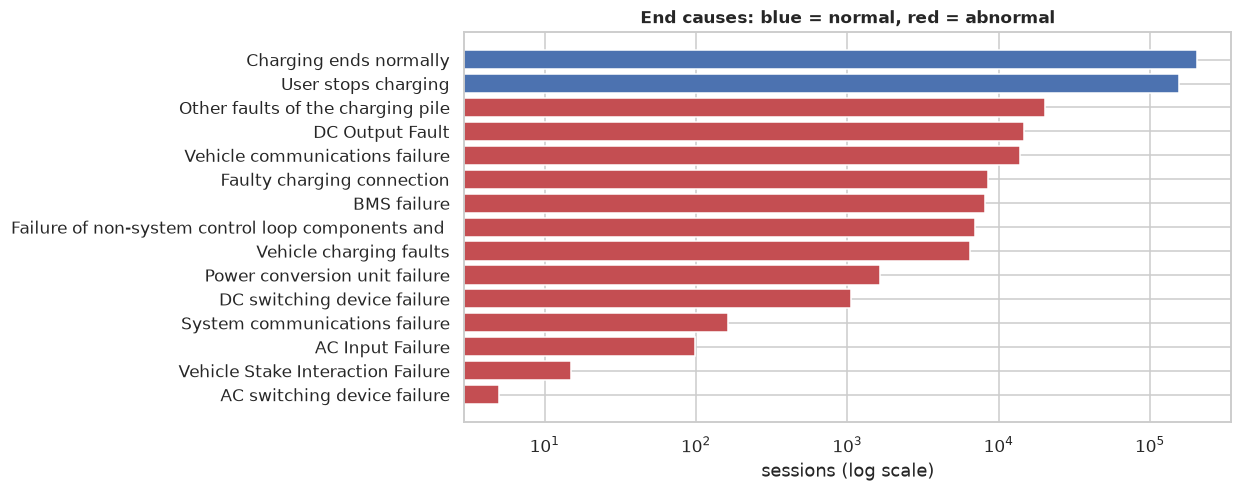

Abnormal: 81,934 sessions (18.58%) | normal: 359,143 | about 1 abnormal for every 4.4 normal
If 'User stops charging' were also abnormal, the abnormal share would be 53.93%


In [12]:
NORMAL_CAUSES = {"Charging ends normally", "User stops charging"}
fault_causes = set(df["end_cause"].unique()) - NORMAL_CAUSES
assert len(fault_causes) == 13 and all(("fault" in c.lower()) or ("failure" in c.lower()) for c in fault_causes)
df[TARGET] = (~df["end_cause"].isin(NORMAL_CAUSES)).astype("int8")

causes = df.groupby("end_cause").agg(
    sessions=("row_id", "size"),
    median_minutes=("duration_h", lambda s: s.median() * 60),
    zero_energy_share=("energy_kwh", lambda s: (s == 0).mean()),
).sort_values("sessions", ascending=False)
causes["label"] = np.where(causes.index.isin(NORMAL_CAUSES), "normal", "abnormal")
display(causes.round(2))

fig, ax = plt.subplots(figsize=(9, 4.6))
c_sorted = causes.sort_values("sessions")
ax.barh(c_sorted.index.str.slice(0, 50), c_sorted["sessions"],
        color=np.where(c_sorted["label"] == "abnormal", C_ABN, C_NORMAL))
ax.set_xscale("log")
ax.set_xlabel("sessions (log scale)")
ax.set_title("End causes: blue = normal, red = abnormal")
savefig(fig, "05_1_end_causes")

share = df[TARGET].mean()
print(f"Abnormal: {df[TARGET].sum():,} sessions ({share:.2%}) | normal: {(df[TARGET] == 0).sum():,} "
      f"| about 1 abnormal for every {(1 - share) / share:.1f} normal")
print(f"If 'User stops charging' were also abnormal, the abnormal share would be "
      f"{(df['end_cause'] != 'Charging ends normally').mean():.2%}")

With this definition 18.58% of the sessions are abnormal, about 1 abnormal for every 4.4 normal ones. The classes are
unbalanced, so accuracy alone would be misleading: a model that always says "normal" is already 81% accurate. The definition
also matters a lot. If user stops counted as abnormal too, the abnormal share would jump to 53.93% and the problem would be
completely different.

The table also shows that most fault causes end after 1–2 minutes and deliver no energy at all, which already suggests that
energy and duration are consequences of the outcome. The 13 fault causes range from 20,114 sessions down to 5, but this does
not matter for a binary target.

### 5.2 Does the data support our definition?

The dataset authors already computed, for each session, the number of earlier abnormal sessions of the same post and of the
same user (for example `post_previous_abnormal_30D`). They used their own definition of "abnormal", which gave us an idea: if
we count the same thing with our label and get the same numbers, the authors most likely used the same definition as us.

A session *j* counts as an earlier session of session *i* if it ended before *i* started (`end_j ≤ start_i`) and inside the
window (the last 30 days). We compare our definition A with an alternative B, where user stops are also abnormal.

In [13]:
def count_previous_abnormal(frame, key, days, label):
    """For every session: how many earlier sessions of the same key (post or user) ended before this session
    started, inside the last `days` days, and were abnormal according to `label`."""
    start = frame["start_time"].to_numpy("datetime64[ns]").astype("int64")
    end = frame["end_time"].to_numpy("datetime64[ns]").astype("int64")
    window = days * 86_400 * 10**9
    result = np.zeros(len(frame), dtype="int64")
    for idx in frame.groupby(key).indices.values():
        order = np.argsort(end[idx])
        ends = end[idx][order]
        cum_abnormal = np.concatenate([[0], np.cumsum(label[idx][order])])
        upto = np.searchsorted(ends, start[idx], side="right")             # ended before (or when) this one started
        since = np.searchsorted(ends, start[idx] - window, side="right")   # ... and inside the window
        result[idx] = cum_abnormal[upto] - cum_abnormal[since]
    return result


options = {"A (ours): normal = ends normally + user stops": NORMAL_CAUSES,
           "B: normal = ends normally only": {"Charging ends normally"}}
agreement = {}
for name, normal in options.items():
    label = (~df["end_cause"].isin(normal)).astype(int).to_numpy()
    agreement[name] = {
        "post, 30 days": (count_previous_abnormal(df, "post_id", 30, label) == df["post_previous_abnormal_30D"]).mean(),
        "user, 30 days": (count_previous_abnormal(df, "user_id", 30, label) == df["user_previous_abnormal_30D"]).mean(),
    }
print("Share of rows where our count equals the column supplied with the dataset:")
display((pd.DataFrame(agreement).T * 100).round(2))

Share of rows where our count equals the column supplied with the dataset:


,"post, 30 days","user, 30 days"
A (ours): normal = ends normally + user stops,100.00,99.98
B: normal = ends normally only,0.26,35.85


In [14]:
# We guessed that the rates are smoothed as (abnormal + 1) / (sessions + 5); here we test it for all six windows
windows = ["post_previous_{}_1D", "post_previous_{}_7D", "post_previous_{}_30D",
           "user_previous_{}_30D", "user_previous_{}_180D", "user_previous_{}_730D"]
max_error = max(
    ((df[w.format("abnormal")] + 1) / (df[w.format("sessions")] + 5) - df[w.format("abnormal_rate")]).abs().max()
    for w in windows)
print(f"Largest difference between the formula and the supplied rate: {max_error:.1e}")
print("Rate of an entity without any history: (0 + 1) / (0 + 5) =", (0 + 1) / (0 + 5))

Largest difference between the formula and the supplied rate: 1.1e-16
Rate of an entity without any history: (0 + 1) / (0 + 5) = 0.2


With definition A our counts match the supplied columns in about 100% of the rows, while with B they match far less often.
So the dataset's history columns were built with the same definition of "abnormal" as ours, and we use definition A as the
target.

This check also taught us two other things. The counts only include sessions that ended before the current one started, so
the history columns contain no information from the future and can be used as predictors. And the rates follow the formula
(abnormal + 1) / (sessions + 5), a smoothing that avoids rates of exactly 0 or 1. Because of it, a post or user without
history always gets the rate 0.2, which is close to, but not the same as, the real abnormal share (0.186). We need to
remember this for new users (cold start, Section 9.5).

### 5.3 Label quality: "normal" sessions that delivered no energy

Since energy is so closely linked to the outcome, we also wanted to see which sessions delivered no energy at all.

In [15]:
zero_energy = df["energy_kwh"].eq(0)
display(pd.crosstab(df[TARGET].map({0: "normal", 1: "abnormal"}), zero_energy.map({False: "energy > 0", True: "energy = 0"})))
zn = df[zero_energy & (df[TARGET] == 0)]
print(f"Normal sessions with zero energy: {len(zn):,} ({len(zn) / (df[TARGET] == 0).sum():.1%} of normal sessions) | "
      f"causes: {zn['end_cause'].value_counts().to_dict()} | median duration: {zn['duration_h'].median() * 60:.2f} min")

energy_kwh,energy = 0,energy > 0
is_Abnormal,,
abnormal,45563,36371
normal,9058,350085


Normal sessions with zero energy: 9,058 (2.5% of normal sessions) | causes: {'User stops charging': 7730, 'Charging ends normally': 1328} | median duration: 0.95 min


As expected for failures, 45,563 abnormal sessions delivered no energy. What surprised us is that 9,058 sessions labelled
normal (2.5% of the normal class) also delivered no energy. Most of them are `User stops charging` after about one minute,
which looks like users who plugged in and changed their mind.

We decided to keep them as normal. To remove them we would need the energy, which is only known after the session, so we
could not apply the same filter when predicting. They add some label noise that a start-time model cannot fix.

In [16]:
log_decision("5", "Target", "is_Abnormal = 1 when end_cause is one of the 13 fault/failure causes; "
             "'Charging ends normally' and 'User stops charging' are normal.",
             "Our counts reproduce the dataset's own previous-abnormal columns in ~100% of rows (alternative B does not). "
             "Share 18.58% (53.93% if user stops were abnormal).")
log_decision("5", "Label noise", "Keep the 9,058 zero-energy sessions labelled normal.",
             "Plausible user cancellations; filtering on energy (post-session) cannot be repeated at prediction time.")

---
## 6. Missing values

The slides say that missing data can take many forms (`<empty>`, `0`, `999`, `unknown`, …). Before choosing a strategy, we
must understand why a value is missing.

> **Note.** From here on, any analysis that guides a modelling decision uses only the training period (2020-04-01 to
> 2021-06-30, chosen in Sections 7 and 11), so that the validation and test periods do not influence our choices. We call
> this subset `dev`. The whole file is only used to describe data quality and changes over time.

In [17]:
df["period"] = np.select([df["start_time"] < BURN_IN_END, df["start_time"] < TRAIN_END, df["start_time"] < VAL_END],
                         ["burn-in", "train", "validation"], "test")
dev = df[df["period"] == "train"]

FLAG_OF = {   # "time since ..." column -> its "no history" indicator
    "post_hours_since_previous_completed_session": "post_no_previous_completed_session",
    "post_hours_since_previous_completed_abnormal": "post_no_previous_completed_abnormal",
    "user_days_since_previous_completed_session": "user_no_previous_completed_session",
    "user_days_since_previous_completed_abnormal": "user_no_previous_completed_abnormal",
}
print("Columns with missing values:", df.columns[df.isna().any()].tolist())
missing = pd.DataFrame({
    "missing": [df[c].isna().sum() for c in FLAG_OF],
    "missing %": [round(df[c].isna().mean() * 100, 2) for c in FLAG_OF],
    "no-history flag = 1": [df[f].eq(1).sum() for f in FLAG_OF.values()],
    "rows where NaN and flag disagree": [(df[c].isna() != df[f].eq(1)).sum() for c, f in FLAG_OF.items()],
}, index=list(FLAG_OF))
display(missing)

Columns with missing values: ['post_hours_since_previous_completed_session', 'post_hours_since_previous_completed_abnormal', 'user_days_since_previous_completed_session', 'user_days_since_previous_completed_abnormal']


,missing,missing %,no-history flag = 1,rows where NaN and flag disagree
post_hours_since_previous_completed_session,92,0.02,92,0
post_hours_since_previous_completed_abnormal,367,0.08,367,0
user_days_since_previous_completed_session,56647,12.84,56647,0
user_days_since_previous_completed_abnormal,136279,30.90,136279,0


In [18]:
# Look for disguised missing values: typical codes in numeric columns and "unknown"-like labels in text columns
numeric_cols = [c for c in raw.select_dtypes("number").columns if c not in ("UserID", "Charging Post ID")]
codes = {c: int(raw[c].isin([-1, -99, -999, 999, 9999]).sum()) for c in numeric_cols}
print("Numeric columns containing -1, -99, -999, 999 or 9999:", {c: n for c, n in codes.items() if n} or "none")
unknown_words = {"unknown", "unk", "na", "n/a", "", "-", "none", "null"}
print("Text labels meaning 'unknown':",
      {c: [v for v in df[c].unique() if str(v).lower() in unknown_words] for c in ["location", "district", "tariff_period", "end_cause"]})

# Does being missing say something about the outcome? (training period only)
info = pd.DataFrame({c: {"abnormal rate if missing": dev.loc[dev[c].isna(), TARGET].mean(),
                         "abnormal rate if present": dev.loc[dev[c].notna(), TARGET].mean(),
                         "missing in training period": int(dev[c].isna().sum())} for c in FLAG_OF}).T
display(info.round(3))

Numeric columns containing -1, -99, -999, 999 or 9999: {'user_previous_sessions_30D': 2, 'user_previous_sessions_180D': 1, 'user_previous_sessions_730D': 4, 'user_previous_abnormal_730D': 1}
Text labels meaning 'unknown': {'location': [], 'district': [], 'tariff_period': [], 'end_cause': []}


,abnormal rate if missing,abnormal rate if present,missing in training period
post_hours_since_previous_completed_session,NaN,0.178,0.0
post_hours_since_previous_completed_abnormal,NaN,0.178,0.0
user_days_since_previous_completed_session,0.203,0.175,32829.0
user_days_since_previous_completed_abnormal,0.144,0.193,80433.0


Only four "time since the previous …" columns have missing values, and every missing value matches its no-history flag, with
0 disagreements. So the value is missing because the event never happened (there was no earlier session, or no earlier
failure), not because it is unknown. This is what is called *structural* missingness. Disguised missing values were not a problem either: the few values equal to 999 or 9999 are ordinary session counts of very active (fleet) accounts, and
no text label means "unknown".

The two post columns are only missing at the very start of the file (the first sessions of each post), so they have no
missing values in the training period. The two user columns stay missing for 12–30% of the sessions, because new users keep
arriving. The missingness also carries information: users with no earlier failure are abnormal less often (see the table).

To decide what to do, we went through the options on the slide *Dealing with missing values*. Deleting the rows would remove
12–30% of the data, and exactly the new users the model must handle. Filling with the mean or median does not make sense,
because "never happened" is not a typical value, and it would also reduce the variance and distort the distribution.
Model-based imputation (regression, kNN) would invent a "plausible" value for something we know never happened. So we do not
delete or impute anything. Tree models can work with `NaN` directly, so for them we keep the `NaN` and the flags. For linear
and distance models we fill the value with the training maximum ("never happened" is close to "a very long time ago") and
keep the flag; this value is learned on the training period only (Section 13).

In [19]:
log_decision("6", "Missing values", "No deletion, no mean/median or model imputation. Trees: keep NaN + flags. "
             "Linear models: fill with the training maximum + keep the flags.",
             "NaN equals the no-history flag in 100% of rows (structural); missingness is related to the outcome.")

---
## 7. Changes over time

The brief asks whether *session volume, class prevalence, predictor distributions and user/post activity remain stable over
time*. This matters for us because, if they change, a random train/test split would give over-optimistic results.

### 7.1 Volume, abnormal share and activity per month

,sessions,abnormal_pct,active_users,active_posts,new_user_pct,mean_post_sessions_30D
start_time,,,,,,
2020-01,6217,25.0,1963,92,31.4,52.8
2020-02,1391,26.3,516,83,23.7,45.1
2020-03,6392,24.8,1797,92,20.9,67.5
2020-04,11136,22.1,2622,92,15.5,160.8
2020-05,15033,19.2,3153,92,12.4,222.4
2020-06,17513,16.0,3185,91,9.7,237.2
2020-07,22032,18.2,3704,92,8.8,272.0
2020-08,25562,20.1,4733,92,10.4,334.1
2020-09,20231,18.6,4642,92,12.7,316.5


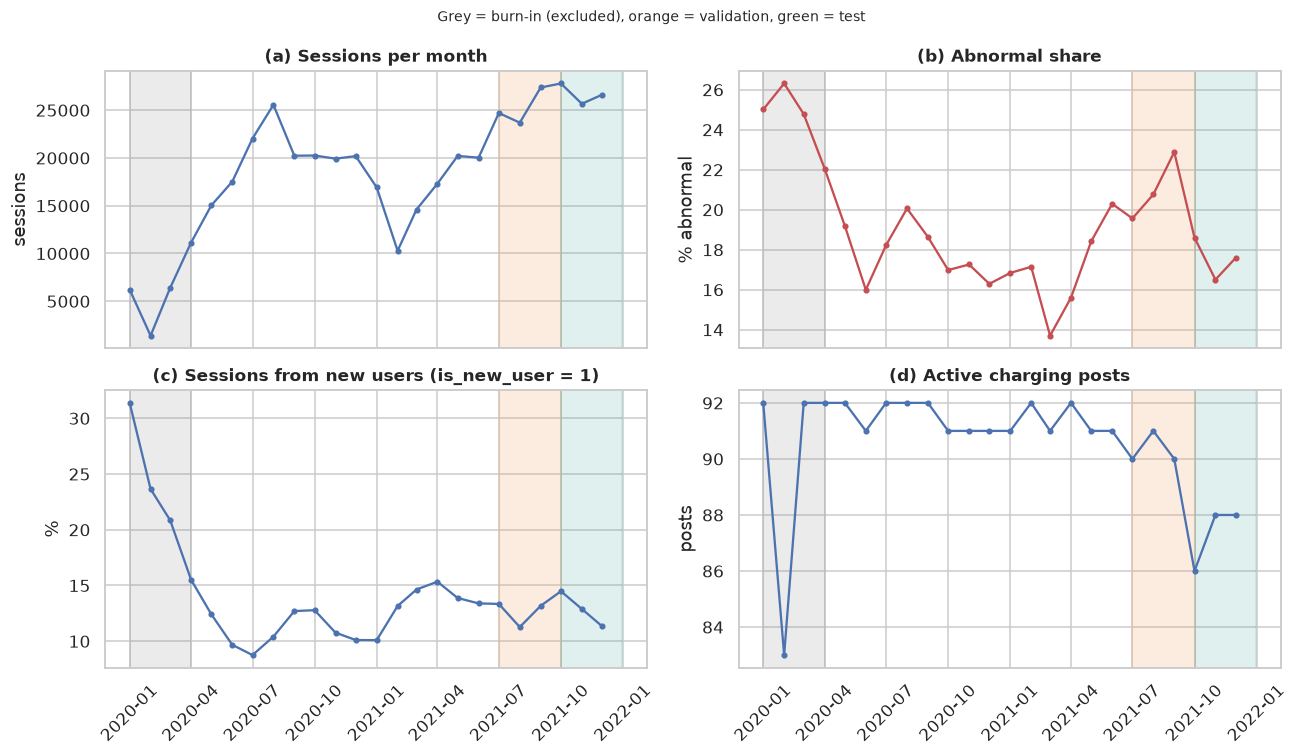

In [20]:
d = df[df["start_time"] >= "2020-01-01"]          # the file starts on the evening of 31-Dec-2019 (17 sessions)
monthly = d.groupby(d["start_time"].dt.to_period("M")).agg(
    sessions=(TARGET, "size"),
    abnormal_pct=(TARGET, "mean"),
    active_users=("user_id", "nunique"),
    active_posts=("post_id", "nunique"),
    new_user_pct=("is_new_user", "mean"),
    mean_post_sessions_30D=("post_previous_sessions_30D", "mean"),
)
monthly[["abnormal_pct", "new_user_pct"]] *= 100
display(monthly.round(1))

x = monthly.index.to_timestamp()
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
panels = [("sessions", "(a) Sessions per month", "sessions"),
          ("abnormal_pct", "(b) Abnormal share", "% abnormal"),
          ("new_user_pct", "(c) Sessions from new users (is_new_user = 1)", "%"),
          ("active_posts", "(d) Active charging posts", "posts")]
for ax, (col, title, ylabel) in zip(axes.ravel(), panels):
    ax.axvspan(x.min(), BURN_IN_END, color=C_GREY, alpha=.15)
    ax.axvspan(TRAIN_END, VAL_END, color="#f4a261", alpha=.2)
    ax.axvspan(VAL_END, x.max() + pd.offsets.MonthEnd(1), color="#2a9d8f", alpha=.15)
    ax.plot(x, monthly[col], marker="o", ms=3, color=C_ABN if col == "abnormal_pct" else C_NORMAL)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Grey = burn-in (excluded), orange = validation, green = test", fontsize=9)
fig.tight_layout()
savefig(fig, "07_1_monthly_volume_prevalence_activity")

Volume changes a lot. It starts at about 6,200 sessions in January 2020 and drops to 1,391 in February 2020, probably because
of the COVID-19 restrictions (this is outside knowledge, not something in the data). It then grows to over 25,000 by August
2020, dips again around February 2021 (Spring Festival) and reaches 25–28k per month in autumn 2021.

The abnormal share moves too. It is 25–26% in Q1-2020, falls to about 16% in mid-2020, reaches its lowest point of 13.7% in
March 2021, rises to 22.9% in September 2021 and ends around 17–19%. With 10–28k sessions per month, we do not think these
are random fluctuations.

The first months look different from the rest. In January 2020, 31% of the sessions come from "new" users, compared with
about 10–15% later, and the 30-day post counts are still filling up. The file starts on 31-Dec-2019, so "new user" really
means first session in the file, not first session ever, and the history columns are incomplete at the start. About 90–92
posts are active every month until September 2021, when four posts stop (Section 7.4).

### 7.2 Does the *type* of failure change?

The abnormal share could stay stable while the type of failure changes underneath, so we grouped the 13 fault causes into four
families and looked at how much each family adds to the abnormal share in each quarter.

end_cause,Connection fault,DC output fault,Other charger faults,Vehicle side
start_time,,,,
2020Q1,7.1,2.9,7.0,8.0
2020Q2,4.0,3.2,6.7,4.7
2020Q3,1.1,5.2,7.2,5.6
2020Q4,1.0,3.3,5.8,6.8
2021Q1,1.1,3.2,5.4,6.2
2021Q2,1.4,3.0,6.8,7.1
2021Q3,2.3,2.9,9.0,6.9
2021Q4,1.9,2.8,6.0,7.0


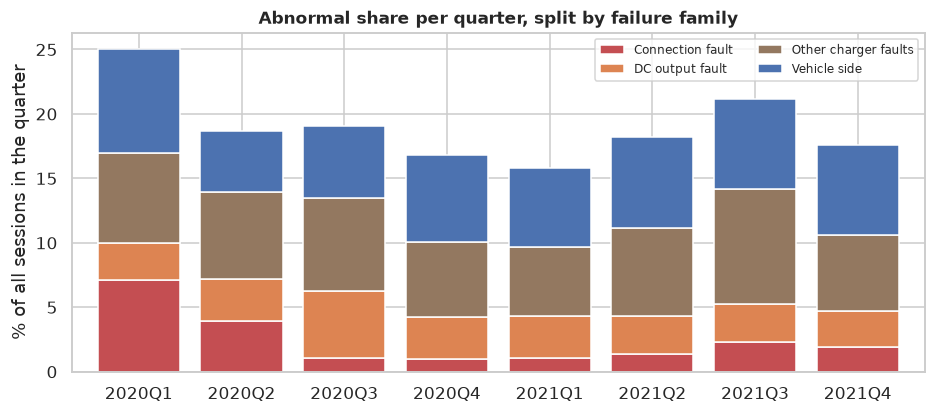

In [21]:
FAMILY = {
    "Faulty charging connection": "Connection fault",
    "DC Output Fault": "DC output fault",
    "Vehicle communications failure": "Vehicle side",
    "BMS failure": "Vehicle side",
    "Vehicle charging faults": "Vehicle side",
    "Vehicle Stake Interaction Failure": "Vehicle side",
}
quarter = d["start_time"].dt.to_period("Q")
abn = d[d[TARGET] == 1]
family = abn["end_cause"].map(FAMILY).fillna("Other charger faults")
contribution = pd.crosstab(quarter[abn.index], family).div(quarter.value_counts().sort_index(), axis=0) * 100
display(contribution.round(1))

fig, ax = plt.subplots(figsize=(10, 4))
contribution.plot(kind="bar", stacked=True, ax=ax, width=.8, color=["#C44E52", "#DD8452", "#937860", "#4C72B0"])
ax.set_ylabel("% of all sessions in the quarter")
ax.set_xlabel("")
ax.set_title("Abnormal share per quarter, split by failure family")
ax.legend(fontsize=8, ncol=2)
plt.xticks(rotation=0)
savefig(fig, "07_2_fault_family_by_quarter")

Connection faults add 7.1 percentage points to the abnormal share in Q1-2020, 4.0 in Q2-2020 and only about 1 from Q3-2020
onwards, while the other families are steadier. So this one family explains most of the early drop in the abnormal share. Our
guess is that it was an early problem that was later fixed, but the data cannot confirm this.

For modelling, this means the start of 2020 shows a failure pattern that no longer exists, which is another reason to leave it
out of training (Section 7.5). It also warns us that the mix of failures could change again after a model is deployed.

### 7.3 Do stations and posts keep the same behaviour?

We also wanted to know whether the risky stations and posts stay risky over time.

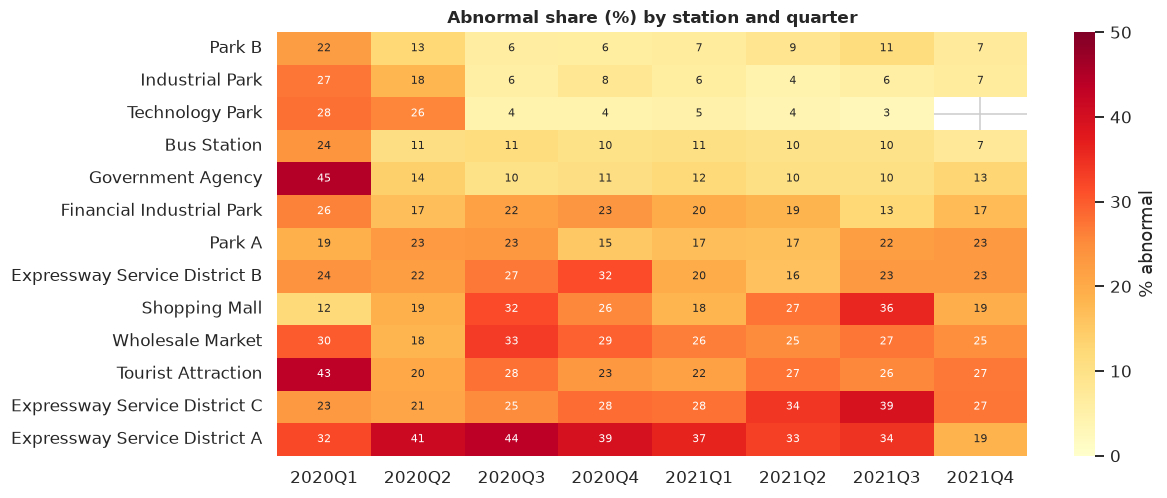

Do posts keep their abnormal share? Spearman correlation between Apr-Dec 2020 and 2021: 0.81 (92 posts)


In [22]:
by_station_q = d.groupby(["location", quarter])[TARGET].agg(["mean", "size"])
heat = (by_station_q["mean"].where(by_station_q["size"] >= 200) * 100).unstack()   # hide cells with < 200 sessions
heat = heat.loc[heat.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", vmin=0, vmax=50, cbar_kws={"label": "% abnormal"}, ax=ax,
            annot_kws={"fontsize": 7})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Abnormal share (%) by station and quarter")
savefig(fig, "07_3_station_by_quarter")

rate_2020 = df[(df["start_time"] >= BURN_IN_END) & (df["start_time"] < "2021-01-01")].groupby("post_id")[TARGET].mean()
rate_2021 = df[df["start_time"] >= "2021-01-01"].groupby("post_id")[TARGET].mean()
print(f"Do posts keep their abnormal share? Spearman correlation between Apr-Dec 2020 and 2021: "
      f"{rate_2020.corr(rate_2021, method='spearman'):.2f} ({rate_2020.index.intersection(rate_2021.index).size} posts)")

Stations differ a lot, and their ranking is fairly stable: Park B, Industrial Park, Technology Park and Bus Station stay low,
while the Expressway Service Districts, Wholesale Market, Shopping Mall and Tourist Attraction stay high. The levels still
move, though. Government Agency goes from 45% in Q1-2020 to 10–14%, and Shopping Mall rises to 36% in Q3-2021, so a fixed
"station effect" would not be enough and recent history is needed to follow these changes.

At the post level, the abnormal shares are persistent (Spearman 0.81 between 2020 and 2021). We think this is why the post's
own history is so useful (Section 9.4).

### 7.4 Do the predictors change? Post life cycle

Here we followed the quarterly median of a few predictors. If the median stays stable, the predictor behaves the same way over
time.

In [23]:
drift_cols = ["post_previous_sessions_30D", "post_previous_abnormal_rate_30D", "post_previous_abnormal_rate_7D",
              "user_previous_abnormal_rate_180D", "user_previous_sessions_180D", "temperature"]
drift = d.groupby(quarter)[drift_cols].median()
drift["new users %"] = d.groupby(quarter)["is_new_user"].mean() * 100
display(drift.round(3))

life = df.groupby("post_id").agg(first_session=("start_time", "min"), last_session=("start_time", "max"),
                                 sessions=("row_id", "size"), location=("location", "first"))
print("Posts that start after 15-Jan-2020:")
display(life[life["first_session"] > "2020-01-15"])
print("Posts with no session in the test period (from 2021-10-01):")
display(life[life["last_session"] < VAL_END])

,post_previous_sessions_30D,post_previous_abnormal_rate_30D,post_previous_abnormal_rate_7D,user_previous_abnormal_rate_180D,user_previous_sessions_180D,temperature,new users %
start_time,,,,,,,
2020Q1,48.0,0.211,0.200,0.200,3.0,9.3,25.807
2020Q2,173.0,0.169,0.152,0.189,16.0,23.4,12.108
2020Q3,319.0,0.123,0.121,0.167,28.0,27.9,10.557
2020Q4,305.0,0.123,0.114,0.167,31.0,14.6,11.222
2021Q1,239.0,0.115,0.119,0.167,20.0,9.6,12.434
2021Q2,266.0,0.127,0.125,0.167,14.0,22.6,14.148
2021Q3,330.0,0.151,0.143,0.181,14.0,28.6,12.634
2021Q4,367.0,0.149,0.141,0.177,15.0,13.1,12.928


Posts that start after 15-Jan-2020:


,first_session,last_session,sessions,location
post_id,,,,
85,2020-01-25 16:32:30,2021-12-31 22:23:49,4661,Wholesale Market


Posts with no session in the test period (from 2021-10-01):


,first_session,last_session,sessions,location
post_id,,,,
17,2020-01-01 15:27:51,2021-09-28 20:08:03,7328,Technology Park
18,2020-01-01 12:14:43,2021-09-28 20:30:53,7426,Technology Park
19,2020-01-01 12:52:10,2021-09-28 19:16:27,6935,Technology Park
20,2020-01-01 11:59:54,2021-09-28 20:51:02,7178,Technology Park


Q1-2020 is again different. For example, the median 30-day post count is much lower than later, because the rolling windows
are still filling up, but after the first months the history rates are fairly stable. Since traffic grows, the counts
(number of earlier sessions) keep increasing while the rates stay in the same range. We expect the rates to generalise better
to future periods than the counts. Temperature follows the seasons, which is normal and not a data problem.

Looking at the posts, only post 85 starts late (25-Jan-2020), and posts 17–20 (Technology Park) stop on 28-Sep-2021, so they
are missing from the test period. No post in validation or test is new, which means our split cannot test what happens with a
new post.

### 7.5 Consequences for modelling

These results changed how we set up the evaluation. Because the history columns are incomplete and the failure mix is
different in Q1-2020 (Sections 7.1, 7.2 and 7.4), we treat the first months as a burn-in and do not use sessions before
2020-04-01 for modelling (14,017 sessions, 3.2% of the file). Because volume, abnormal share and failure mix change over
time, we use a chronological split instead of a random one: training from Apr-2020 to Jun-2021, validation in 2021-Q3 and
test in 2021-Q4 (Section 11).

The abnormal share also differs between periods (13.7%–22.9%), so results should always be compared with the abnormal share
of the same period, and the decision thresholds may need adjusting. Finally, since counts grow with traffic and rates are
stable, we prefer the rates as the main history signal and keep an eye on the counts.

In [24]:
log_decision("7", "Burn-in", "Do not use sessions before 2020-04-01 for modelling.",
             "History columns incomplete at file start (new users 31% vs ~13%); different failure mix in Q1-2020.")
log_decision("7", "Time split", "Chronological split, no random split.",
             "Volume, abnormal share (13.7%-26.3%) and failure mix change over time.")

---
## 8. Leakage and availability at the start

### 8.1 How much do the "after the session" columns know about the outcome?

To measure this, we computed the univariate ROC-AUC of each variable on the training period. It tells us how well that one
variable alone separates normal from abnormal sessions (0.5 means not at all, 1.0 means perfectly). A variable that measures
the *result* of the session should separate the classes very well, and that is exactly what makes it a leaker rather than a
good predictor.

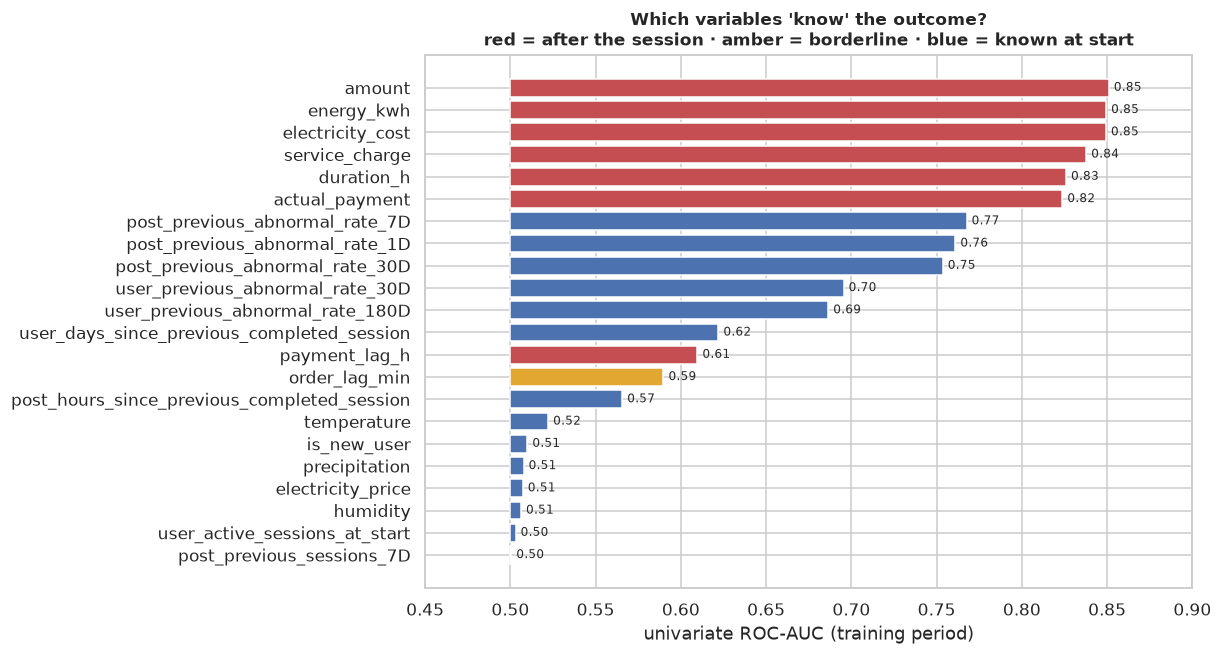

In [25]:
candidates = {
    "energy_kwh": "after", "electricity_cost": "after", "service_charge": "after", "amount": "after",
    "actual_payment": "after", "duration_h": "after", "payment_lag_h": "after",
    "order_lag_min": "borderline",
    "post_previous_abnormal_rate_7D": "at start", "post_previous_abnormal_rate_30D": "at start",
    "post_previous_abnormal_rate_1D": "at start", "user_previous_abnormal_rate_180D": "at start",
    "user_previous_abnormal_rate_30D": "at start", "post_hours_since_previous_completed_session": "at start",
    "user_days_since_previous_completed_session": "at start", "post_previous_sessions_7D": "at start",
    "is_new_user": "at start", "user_active_sessions_at_start": "at start",
    "temperature": "at start", "humidity": "at start", "precipitation": "at start", "electricity_price": "at start",
}
# NaN filled with the median only for this quick AUC check, not in the real pipeline
leak = pd.DataFrame({
    "known": pd.Series(candidates),
    "AUC": {c: auc(dev[TARGET], dev[c].fillna(dev[c].median())) for c in candidates},
}).sort_values("AUC")

fig, ax = plt.subplots(figsize=(9, 6.3))
colors = leak["known"].map({"after": C_ABN, "borderline": "#E1A730", "at start": C_NORMAL})
ax.barh(leak.index, leak["AUC"] - 0.5, left=0.5, color=colors)
for i, v in enumerate(leak["AUC"]):
    ax.text(v + .003, i, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlim(0.45, 0.9)
ax.set_xlabel("univariate ROC-AUC (training period)")
ax.set_title("Which variables 'know' the outcome?\nred = after the session · amber = borderline · blue = known at start")
savefig(fig, "08_1_univariate_auc_by_availability")

The after-session variables (energy, money, duration) reach an AUC of 0.82–0.85 on their own, higher than any variable known
at the start (best about 0.77). Abnormal sessions are short and deliver little energy (Section 5.1), so these variables
describe the outcome instead of predicting it. A model trained on them would only learn to recognise a session that has
already failed.

Among the legitimate variables, post history comes first (0.75–0.77), then user history (about 0.69–0.70), then the
time-since variables, while weather, tariff and concurrency stay close to 0.5 (0.50–0.52). This only gives us an
expectation, because a single-variable AUC ignores interactions.

### 8.2 The unclear timestamp: `Order creation time`

Section 4.2 showed that the order time is often stamped after the start, so we looked at the delay in more detail.

In [26]:
bins = [-np.inf, -3, -1, 0, 1, 3, 10, 60, np.inf]
labels = ["< -3 min", "-3 to -1", "-1 to 0", "0 to +1", "+1 to +3", "+3 to +10", "+10 to +60", "> +60"]
lag = abnormal_rate(dev.assign(lag_bin=pd.cut(dev["order_lag_min"], bins=bins, labels=labels)), "lag_bin")
lag["share of sessions"] = lag["sessions"] / lag["sessions"].sum()
display(lag.round(3))
print(f"Order stamped after the start: {(dev['order_lag_min'] > 0).mean():.1%} of training sessions | "
      f"maximum delay: {dev['order_lag_min'].max():,.0f} min | AUC of the delay: {auc(dev[TARGET], dev['order_lag_min']):.2f}")

,sessions,abnormal_rate,share of sessions
lag_bin,,,
-3 to -1,14095,0.177,0.052
-1 to 0,102023,0.241,0.376
0 to +1,79921,0.150,0.295
+1 to +3,70682,0.113,0.261
+3 to +10,3522,0.287,0.013
+10 to +60,899,0.209,0.003
> +60,68,0.088,0.000


Order stamped after the start: 57.2% of training sessions | maximum delay: 972 min | AUC of the delay: 0.59


In 57.2% of the training sessions the order is stamped after the start, by up to 16 hours (and by days elsewhere in the file).
So we cannot be sure that the order time exists when we make the prediction. Its link to the outcome is also weak and
irregular (AUC 0.59). We think the delay reflects how the start procedure went, which is only known once the session has
begun, so we exclude it.

### 8.3 Decision on availability

Putting everything together, this is what we consider known at the start, and under which condition:

| Group | Known at start? | Condition in practice |
|-------|-----------------|-----------------------|
| Calendar, tariff | yes | none, it comes from the start time |
| Location (post, station, district) | yes | the post is known when the car is plugged in |
| Weather | assumed | a daily forecast must exist; if it were a measured daily value it would leak |
| Post history | yes | only sessions that ended before the start are counted (checked in Section 5.2) |
| User history | yes, if the account is identified | requires linking the session to an account (privacy, Section 9.5) |
| Concurrency | yes | the platform knows which sessions of the account are running |
| `Order creation time` | unclear | excluded |
| Energy, money, end time, payment time, `end_cause` | no | excluded (leakers) |

In [27]:
log_decision("8", "Leakers", "Exclude energy, the four money columns, end_time, payment_time and end_cause from the predictors.",
             "Only known after the session; univariate AUC 0.82-0.85, higher than any start-time variable.")
log_decision("8", "Order creation time", "Exclude from the predictors.",
             "Stamped after the start in 57.2% of training sessions; weak, irregular signal (AUC 0.59).")

---
## 9. Exploring the start-time predictors (training period)

For each group of predictors we wanted to see whether it separates normal from abnormal sessions, by how much, and what that
means for the preparation. In the plots, the dashed line is the overall abnormal share of the training period.

### 9.1 Location: district, station and post

,sessions,abnormal %
district,,
Nanhu,47467,16.3
Tongxiang,139891,14.6
Xiuzhou,83852,24.1


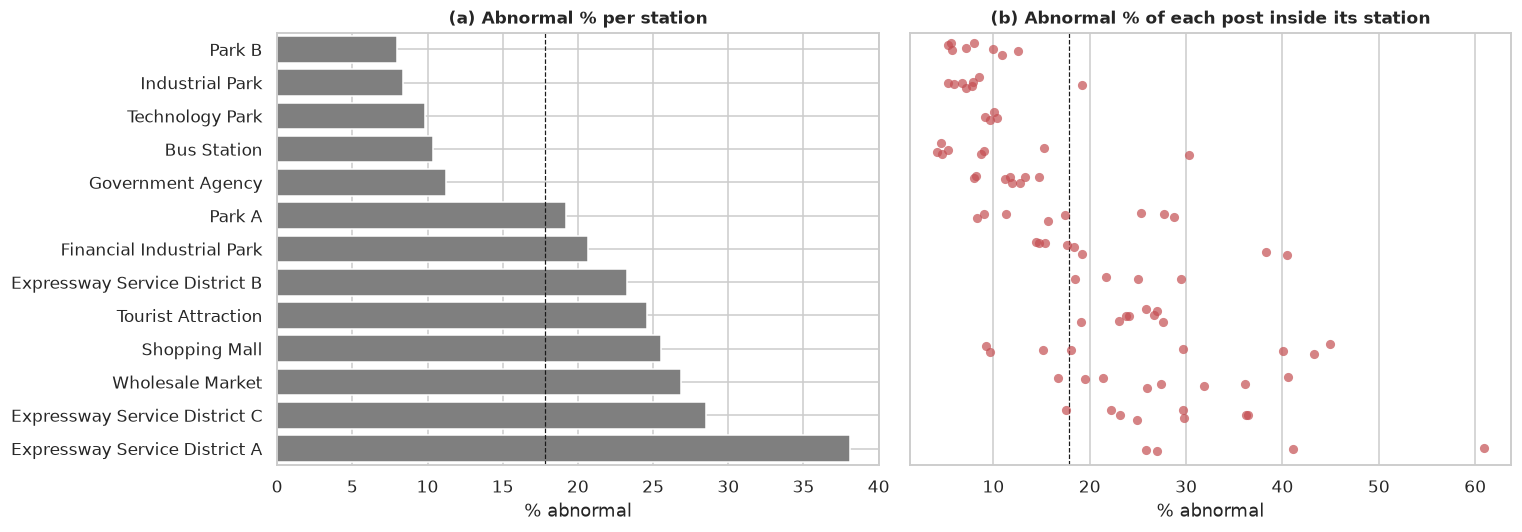

Post abnormal share: min 4.1%, max 60.9% | the 10 worst posts have 24.1% of the abnormal sessions but 10.2% of all sessions


In [28]:
overall = dev[TARGET].mean() * 100
display((abnormal_rate(dev, "district") * [1, 100]).round(1).rename(columns={"abnormal_rate": "abnormal %"}))
by_station = abnormal_rate(dev, "location").sort_values("abnormal_rate")
by_post = abnormal_rate(dev, "post_id").join(dev.groupby("post_id")["location"].first())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].barh(by_station.index, by_station["abnormal_rate"] * 100, color=C_GREY)
axes[0].set_title("(a) Abnormal % per station")
sns.stripplot(x=by_post["abnormal_rate"] * 100, y=by_post["location"], order=by_station.index, ax=axes[1],
              color=C_ABN, size=6, alpha=.7, jitter=.2)
axes[1].set_title("(b) Abnormal % of each post inside its station")
for ax in axes:
    ax.axvline(overall, color="k", ls="--", lw=.8)
    ax.set_xlabel("% abnormal")
    ax.set_ylabel("")
fig.tight_layout()
savefig(fig, "09_1_location_and_posts")

post_rate = by_post["abnormal_rate"]
top10 = by_post.sort_values("abnormal_rate", ascending=False).head(10)
print(f"Post abnormal share: min {post_rate.min():.1%}, max {post_rate.max():.1%} | "
      f"the 10 worst posts have {(top10['abnormal_rate'] * top10['sessions']).sum() / dev[TARGET].sum():.1%} "
      f"of the abnormal sessions but {top10['sessions'].sum() / len(dev):.1%} of all sessions")

District matters a little (14.6% to 24.1%), and stations differ more, from about 8% (Park B) to 38% (Expressway A). What we
did not expect is how much the posts differ inside the same station: the Shopping Mall posts, for example, range from about
9% to 45%. Something specific to each post (for example hardware or maintenance) seems to matter, and failures are
concentrated in a few posts. The post shares go from 4.1% to 60.9%, and the 10 worst posts produce 24.1% of the abnormal
sessions with only 10.2% of all sessions.

So the post is the most informative location level. We still keep `location` and `district` as coarser fall-backs for a post
that has never been seen before.

### 9.2 Hour, day of week and tariff period

hour: abnormal % from 14.7% to 20.5%
day_of_week: abnormal % from 17.0% to 18.9%
tariff_period: abnormal % from 15.6% to 20.2%


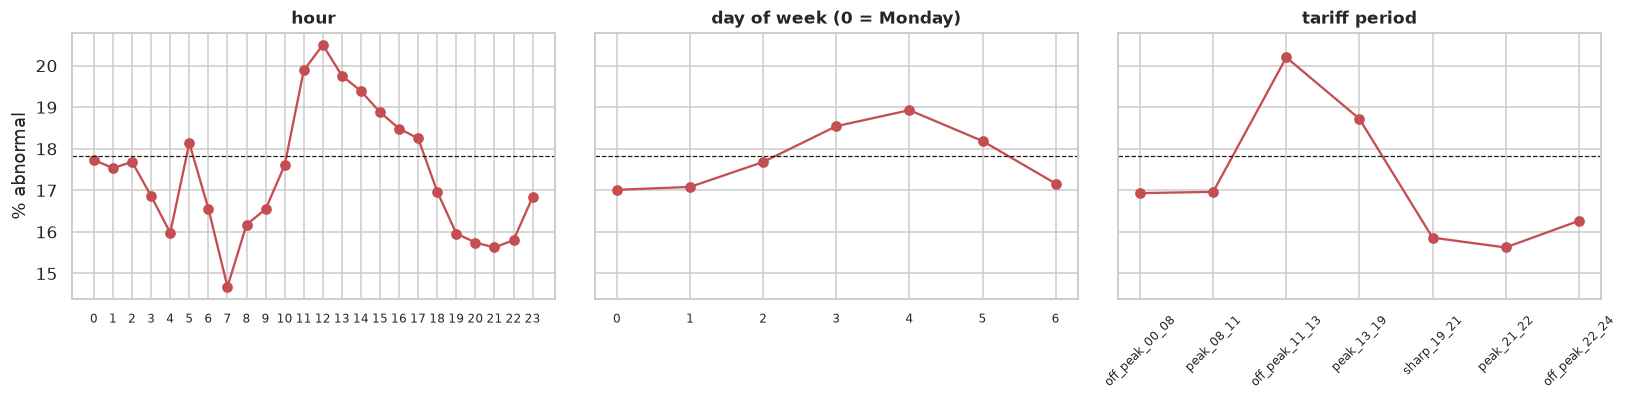

In [29]:
cal = dev.assign(hour=dev["start_time"].dt.hour, day_of_week=dev["start_time"].dt.dayofweek)
tariff_order = ["off_peak_00_08", "peak_08_11", "off_peak_11_13", "peak_13_19", "sharp_19_21", "peak_21_22", "off_peak_22_24"]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, col in zip(axes, ["hour", "day_of_week", "tariff_period"]):
    t = abnormal_rate(cal, col)
    if col == "tariff_period":
        t = t.loc[tariff_order]
    ax.plot(range(len(t)), t["abnormal_rate"] * 100, "o-", color=C_ABN)
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels(t.index, rotation=45 if col == "tariff_period" else 0, fontsize=8)
    ax.axhline(overall, color="k", ls="--", lw=.8)
    ax.set_title(col.replace("_", " ") + (" (0 = Monday)" if col == "day_of_week" else ""))
    print(f"{col}: abnormal % from {t['abnormal_rate'].min():.1%} to {t['abnormal_rate'].max():.1%}")
axes[0].set_ylabel("% abnormal")
fig.tight_layout()
savefig(fig, "09_2_calendar_and_tariff")

The calendar effects are small. The abnormal share moves by only a few points across the hours, with midday slightly riskier,
and the days of the week are close to each other (17.0% to 18.9%). The tariff curve copies the hour curve, which makes sense
because the tariff period is just a grouping of the hour (Section 4.3).

We still keep the hour, the day of week and the tariff period. Hour and day of week are *circular* (23h is next to 0h), so they
get a special encoding in Section 13. We expect them to add little, and the group ablation in Task 2 will measure it.

### 9.3 Weather

To explore the weather we cut it into bins with domain-based cut points (the *custom discretisation* from the slides). The bins
are only for these plots; the models will receive the continuous values (Section 12.6).

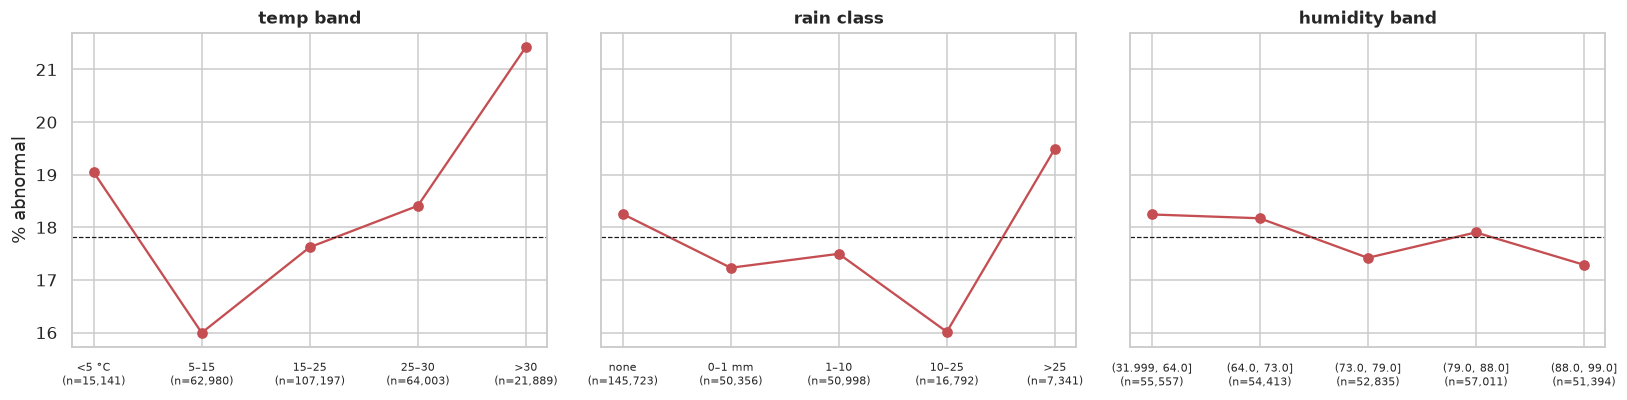

,temperature,humidity,precipitation
temperature,1.00,0.17,0.06
humidity,0.17,1.00,0.70
precipitation,0.06,0.70,1.00


Sessions on rainy days: 46.3%


In [30]:
w = dev.assign(
    temp_band=pd.cut(dev["temperature"], [-np.inf, 5, 15, 25, 30, np.inf], labels=["<5 °C", "5–15", "15–25", "25–30", ">30"]),
    rain_class=pd.cut(dev["precipitation"], [-np.inf, 0, 1, 10, 25, np.inf],
                      labels=["none", "0–1 mm", "1–10", "10–25", ">25"]),
    humidity_band=pd.qcut(dev["humidity"], 5),
)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, col in zip(axes, ["temp_band", "rain_class", "humidity_band"]):
    t = abnormal_rate(w, col)
    ax.plot(range(len(t)), t["abnormal_rate"] * 100, "o-", color=C_ABN)
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([f"{i}\n(n={n:,})" for i, n in zip(t.index, t["sessions"])], fontsize=7)
    ax.axhline(overall, color="k", ls="--", lw=.8)
    ax.set_title(col.replace("_", " "))
axes[0].set_ylabel("% abnormal")
fig.tight_layout()
savefig(fig, "09_3_weather")
display(dev[["temperature", "humidity", "precipitation"]].corr(method="spearman").round(2))
print(f"Sessions on rainy days: {(dev['precipitation'] > 0).mean():.1%}")

The weather effects are weak and not linear. Temperature is U-shaped (cold and hot days are slightly riskier), rain is
irregular and humidity is almost flat. Humidity and precipitation are related (Spearman 0.70), and precipitation is zero on
about half of the days, with a long tail.

Another thing we realised is that weather has one value per district and day, so there are only about 1,400 different weather
situations, not 271k. This makes it easy to over-fit, and weather is mixed up with the season and with the changes over time
from Section 7. We keep the three variables as one group, without expecting much from them, and add a `rain_flag` (rain
yes/no). Linear models get precipitation on a log scale (Sections 12 and 13).

### 9.4 History columns: the main signal

Each panel splits a history variable into 10 equal-size groups (deciles, only to draw the plot) and shows the abnormal share in
each group. The steeper the curve, the better the variable separates the classes.

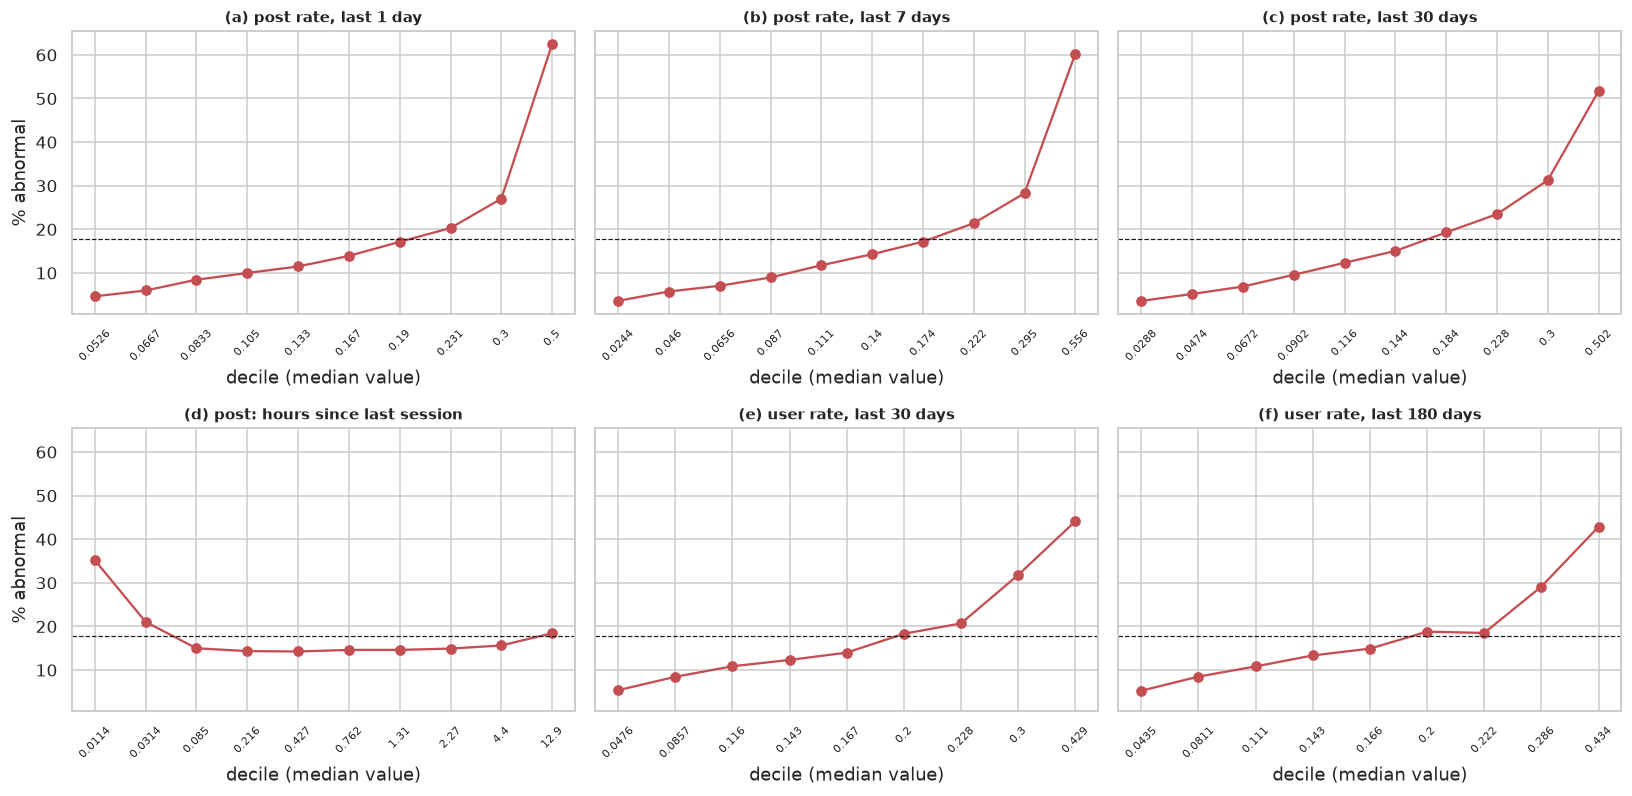

In [31]:
def decile_curve(ax, col, title):
    data = dev.dropna(subset=[col])
    groups = pd.qcut(data[col], 10, duplicates="drop")
    t = data.groupby(groups, observed=True).agg(median=(col, "median"), rate=(TARGET, "mean"))
    ax.plot(range(len(t)), t["rate"] * 100, "o-", color=C_ABN)
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([f"{v:.3g}" for v in t["median"]], rotation=45, fontsize=7)
    ax.axhline(overall, color="k", ls="--", lw=.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("decile (median value)")


panels = [("post_previous_abnormal_rate_1D", "(a) post rate, last 1 day"),
          ("post_previous_abnormal_rate_7D", "(b) post rate, last 7 days"),
          ("post_previous_abnormal_rate_30D", "(c) post rate, last 30 days"),
          ("post_hours_since_previous_completed_session", "(d) post: hours since last session"),
          ("user_previous_abnormal_rate_30D", "(e) user rate, last 30 days"),
          ("user_previous_abnormal_rate_180D", "(f) user rate, last 180 days")]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), sharey=True)
for ax, (col, title) in zip(axes.ravel(), panels):
    decile_curve(ax, col, title)
for ax in axes[:, 0]:
    ax.set_ylabel("% abnormal")
fig.tight_layout()
savefig(fig, "09_4_history_deciles")

In [32]:
# Univariate ranking of every legitimate numeric column (a simple "filter method" from the slides)
legit_numeric = (["temperature", "humidity", "precipitation", "electricity_price", "user_active_sessions_at_start"]
                 + POST_HIST + USER_HIST)
ranking = pd.DataFrame({
    "group": ["post history" if c in POST_HIST else "user history" if c in USER_HIST else "context" for c in legit_numeric],
    "AUC": [auc(dev[TARGET], dev[c].fillna(dev[c].median())) for c in legit_numeric],
    "missing %": [dev[c].isna().mean() * 100 for c in legit_numeric],
    "skewness": [dev[c].skew() for c in legit_numeric],
}, index=legit_numeric).sort_values("AUC", ascending=False)
display(ranking.round(3))

,group,AUC,missing %,skewness
post_previous_abnormal_rate_7D,post history,0.768,0.000,2.287
post_previous_abnormal_rate_1D,post history,0.761,0.000,2.190
post_previous_abnormal_rate_30D,post history,0.754,0.000,2.061
post_hours_since_previous_completed_abnormal,post history,0.732,0.000,7.800
post_previous_abnormal_7D,post history,0.729,0.000,4.302
post_previous_abnormal_1D,post history,0.727,0.000,5.304
post_previous_abnormal_30D,post history,0.708,0.000,3.292
user_previous_abnormal_rate_30D,user history,0.695,0.000,1.521
user_previous_abnormal_rate_180D,user history,0.686,0.000,1.519
user_previous_abnormal_rate_730D,user history,0.685,0.000,1.539


Post history has strong and steady gradients. From the lowest to the highest decile of the 7-day post rate, the abnormal share
goes from about 4% to about 60%; in simple terms, a post that failed recently tends to fail again. The 1-day rate reacts
fastest and the 30-day rate is smoother, so the three windows describe different time scales. The time since the post's last
session is U-shaped: very quick restarts (seconds to minutes) are risky, which looks like retries after a failure, and very
long gaps are risky too.

User history also has a clear gradient, but a weaker one. Users without history get the rate 0.2 (Section 5.2), which puts them
in the middle. In the ranking, the post-history columns are at the top (AUC about 0.71–0.77), followed by user history (about
0.67–0.70), while the context variables (weather, tariff, concurrency) are close to 0.5. Many count and time-since columns are very skewed (skewness 3–9), which will matter for linear models (Sections 10 and 13).

### 9.5 Users: concentration, cold start and privacy

In [33]:
per_user = dev.groupby("user_id").agg(sessions=(TARGET, "size"), posts_used=("post_id", "nunique"))
top1pct = per_user["sessions"].sort_values(ascending=False).head(len(per_user) // 100).sum() / len(dev)
print(f"Accounts: {len(per_user):,} | median sessions per account: {per_user['sessions'].median():.0f} | "
      f"accounts with one session: {(per_user['sessions'] == 1).mean():.1%} | top 1% of accounts hold {top1pct:.1%} of sessions")
display(per_user.sort_values("sessions", ascending=False).head(5))

cold = pd.DataFrame({
    "sessions": [dev["is_new_user"].eq(1).sum(), dev["is_new_user"].eq(0).sum(),
                 dev["user_no_previous_completed_abnormal"].eq(1).sum(), dev["user_no_previous_completed_abnormal"].eq(0).sum()],
    "abnormal %": [dev.loc[dev["is_new_user"].eq(1), TARGET].mean(), dev.loc[dev["is_new_user"].eq(0), TARGET].mean(),
                   dev.loc[dev["user_no_previous_completed_abnormal"].eq(1), TARGET].mean(),
                   dev.loc[dev["user_no_previous_completed_abnormal"].eq(0), TARGET].mean()],
}, index=["new user (is_new_user = 1)", "returning user", "user without an earlier failure", "user with an earlier failure"])
cold["share of sessions %"] = cold["sessions"] / len(dev) * 100
cold["abnormal %"] *= 100
display(cold.round(1))

active = abnormal_rate(dev.assign(active=dev["user_active_sessions_at_start"].clip(upper=3)), "active")
display(active.rename(index={3: "3 or more"}).round(3))

Accounts: 34,294 | median sessions per account: 2 | accounts with one session: 44.9% | top 1% of accounts hold 34.2% of sessions


,sessions,posts_used
user_id,,
39,9044,92
23,3308,92
7841,905,41
1087,864,43
35,748,22


,sessions,abnormal %,share of sessions %
new user (is_new_user = 1),32561,20.2,12.0
returning user,238649,17.5,88.0
user without an earlier failure,80433,14.4,29.7
user with an earlier failure,190777,19.3,70.3


,sessions,abnormal_rate
active,,
0,258953,0.177
1,6471,0.243
2,1946,0.165
3 or more,3840,0.141


The users are very concentrated. There are 34,294 accounts in the training period, and about 45% of them have a single
session, but the top 1% of accounts hold about a third of all sessions. The largest accounts have thousands of sessions on all
92 posts, so they are probably fleet or operator accounts (we cannot verify this).

New users are 12% of the sessions. Their abnormal share is a bit higher (20.2% against 17.5%), and for them the user history is
empty or equal to 0.2. Users with an earlier failure fail more often (19.3% against 14.4%). Concurrency (other sessions of the
same account already running) has only a small, irregular effect.

This has three consequences for us. `user_id` is a key field with 56k values, so we do not use it as a feature (the slides list
key fields among the features to remove); most test sessions come from accounts never seen in training anyway (Section 11),
and the history columns are a better substitute. User history is also a behaviour profile linked to a persistent account ID,
so for privacy reasons it should only be used if it adds clear value over the post information, which Task 2 will test with
the group ablation. Finally, the history columns still work for new users (through the post history), but not for brand-new
posts.

---
## 10. Outliers

The slides say that outliers *have distinct characteristics from most of the other objects, but they may be valid*. So we first
detect them, then check whether they are valid, and only then choose between keeping, transforming, capping or removing them.

### 10.1 Detection with Tukey's fences (IQR)

We used the boxplot rule from the slides: a value is an outlier when it falls outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

,median,99th pct,max,skewness,IQR = 0,% outside fences
post_hours_since_previous_completed_session,0.575833,26.116492,2259.230556,66.082721,False,12.323661
user_active_sessions_at_start,0.0,3.0,14,8.683977,True,4.519376
post_hours_since_previous_completed_abnormal,19.894444,395.643472,2307.641111,7.799646,False,9.158954
user_days_since_previous_completed_session,0.715984,138.311847,533.24213,7.691429,False,15.150956
user_previous_sessions_30D,9.0,1934.0,2605,7.427716,False,6.719148
precipitation,0.0,36.2,152.1,6.83294,False,16.458464
user_previous_sessions_180D,21.0,4825.82,6495,6.29051,False,10.839202
user_previous_sessions_730D,24.0,7233.0,9946,6.232334,False,11.513219
user_previous_abnormal_30D,1.0,260.0,329,6.21433,False,11.060802
user_previous_abnormal_730D,3.0,1123.0,1547,5.995042,False,12.678367


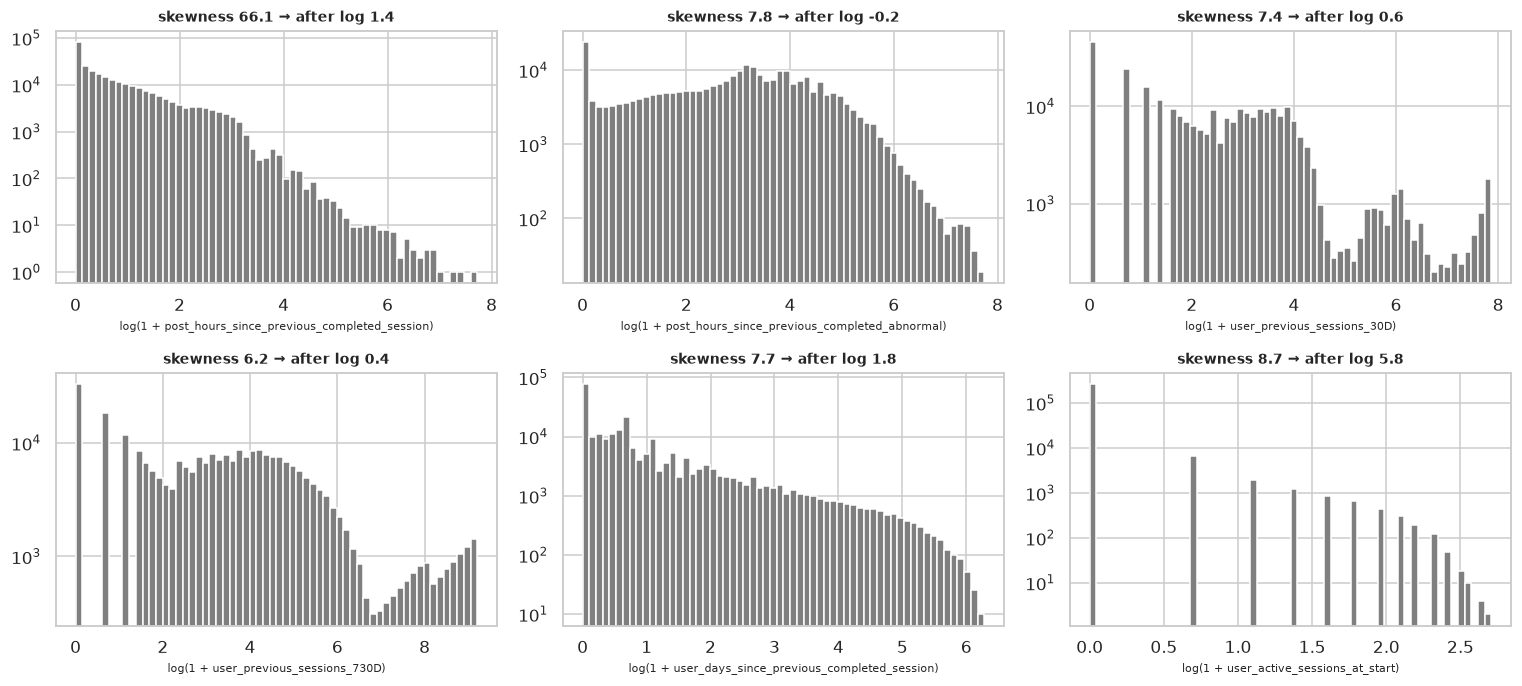

In [34]:
cont_cols = [c for c in legit_numeric if dev[c].nunique() > 2 and c != "electricity_price"]


def tukey(s):
    s = s.dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    outside = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return {"median": s.median(), "99th pct": s.quantile(.99), "max": s.max(), "skewness": s.skew(),
            "IQR = 0": iqr == 0, "% outside fences": outside.mean() * 100}


outliers = pd.DataFrame({c: tukey(dev[c]) for c in cont_cols}).T.sort_values("skewness", ascending=False)
display(outliers.round(2))

heavy = ["post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal",
         "user_previous_sessions_30D", "user_previous_sessions_730D",
         "user_days_since_previous_completed_session", "user_active_sessions_at_start"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.4))
for ax, c in zip(axes.ravel(), heavy):
    values = np.log1p(dev[c].dropna())
    ax.hist(values, bins=60, color=C_GREY)
    ax.set_yscale("log")
    ax.set_xlabel(f"log(1 + {c})", fontsize=7)
    ax.set_title(f"skewness {dev[c].skew():.1f} → after log {values.skew():.1f}", fontsize=9)
fig.tight_layout()
savefig(fig, "10_1_skewed_features_log_scale")

The post and user rates and the weather variables are well behaved. The counts and time-since variables, on the other hand,
have long right tails (skewness 3–9, and much more for the post idle time). For zero-inflated variables like
`user_active_sessions_at_start` the IQR is 0, so the fences flag every non-zero value and the "% outside fences" number means
nothing there. A log transformation (which the slides suggest for severe skewness) brings most of these variables below
skewness 2.

This only tells us that the values are extreme, not whether they are wrong, so we checked that next.

### 10.2 Are the extremes errors or real situations?

We picked the three most extreme situations and looked at them directly.

In [35]:
# (a) a post that was idle for more than 14 days
long_gap = dev[dev["post_hours_since_previous_completed_session"] > 24 * 14]
print(f"(a) Sessions after a post was idle for > 14 days: {len(long_gap)} on {long_gap['post_id'].nunique()} posts | "
      f"abnormal {long_gap[TARGET].mean():.1%} vs {dev[TARGET].mean():.1%} overall")

# (b) accounts with very many sessions
sessions_per_user = dev.groupby("user_id").size()
big_users = sessions_per_user[sessions_per_user > 500].index
big = dev[dev["user_id"].isin(big_users)]
print(f"(b) Accounts with > 500 sessions: {len(big_users)} | {len(big) / len(dev):.1%} of sessions | "
      f"abnormal {big[TARGET].mean():.1%} vs {dev.loc[~dev['user_id'].isin(big_users), TARGET].mean():.1%} for the others | "
      f"median posts used: {big.groupby('user_id')['post_id'].nunique().median():.0f}")

# (c) very heavy rain
storm = df[df["precipitation"] >= 100]
print("(c) Days with at least 100 mm of rain:")
display(storm.groupby(["district", storm["start_time"].dt.date])
        .agg(precipitation=("precipitation", "first"), humidity=("humidity", "first"),
             temperature=("temperature", "first"), sessions=("row_id", "size")))

(a) Sessions after a post was idle for > 14 days: 41 on 26 posts | abnormal 39.0% vs 17.8% overall
(b) Accounts with > 500 sessions: 21 | 9.1% of sessions | abnormal 15.1% vs 18.1% for the others | median posts used: 41
(c) Days with at least 100 mm of rain:


precipitation  humidity  temperature  sessions
district start_time                                                
Nanhu    2020-08-05          152.1        87         28.7       159
         2021-09-10          151.4        91         25.6       144
Xiuzhou  2021-09-10          151.4        91         25.6       349

### 10.3 Multivariate check with Isolation Forest

Univariate fences cannot see unusual combinations of values, so we also tried an Isolation Forest (one of the ML methods for
outliers in the slides). It flags the 1% most isolated sessions in a sample of 60,000 training sessions. Before fitting it, we
log-transformed the skewed columns and standardised everything.

In [36]:
sample = dev.sample(60_000, random_state=SEED)
X_iso = sample[cont_cols].copy()
skewed = [c for c in cont_cols if dev[c].skew() > 1]
X_iso[skewed] = np.log1p(X_iso[skewed])
X_iso = StandardScaler().fit_transform(X_iso.fillna(X_iso.max()))
flagged = IsolationForest(n_estimators=200, contamination=0.01, random_state=SEED).fit_predict(X_iso) == -1

display(pd.DataFrame({
    "flagged (1%)": [flagged.sum(), sample.loc[flagged, TARGET].mean(), sample.loc[flagged, "user_id"].isin(big_users).mean()],
    "other sessions": [(~flagged).sum(), sample.loc[~flagged, TARGET].mean(), sample.loc[~flagged, "user_id"].isin(big_users).mean()],
}, index=["sessions", "abnormal share", "share from accounts with > 500 sessions"]).round(3))

,flagged (1%),other sessions
sessions,600.000,59400.000
abnormal share,0.597,0.174
share from accounts with > 500 sessions,0.552,0.084


The extreme cases turned out to be real. When a post comes back after more than 14 days without sessions, the next sessions
are abnormal about twice as often as usual. These are posts coming back into service after an outage or maintenance, which is
a real and informative situation. The 21 accounts with more than 500 sessions each use dozens of different posts; they are
fleet or operator accounts, and their abnormal share is close to (slightly below) the others'. They are not errors, they just
work at a larger scale. The ~150 mm rain values fall on two storm days with high humidity and summer temperatures, which makes
physical sense.

The Isolation Forest points in the same direction. The most isolated sessions come mostly from the heavy accounts and have a
much higher abnormal share, so they are unusual but valid and informative.

For these reasons we never remove outliers: they are real operating situations, and removing them would hide exactly the
risky cases. For tree models we keep the values as they are, because trees split on the order of the values and not on their
size (the slides note that outliers do not affect them). For linear and distance models we also keep them, but apply `log1p`
to the skewed columns and standardise (Section 13), which reduces the influence of the long tails.

In [37]:
log_decision("10", "Outliers", "Keep all observations. Trees: no change. Linear models: log1p on skewed columns + standardisation.",
             "Extremes are valid: idle posts (~2x abnormal), fleet accounts, real storm days; Isolation Forest agrees.")

---
## 11. Data selection: time split and sampling

### 11.1 Chronological split with a purge

Following Section 7.5, we split the data by start time:
* burn-in: `start < 2020-04-01`, not used for modelling;
* train: `2020-04-01 ≤ start < 2021-07-01`;
* validation: `2021-07-01 ≤ start < 2021-10-01`, to compare models and choose thresholds;
* test: `start ≥ 2021-10-01`, used only once at the end.

One more step is needed, a purge. We only learn whether a session was abnormal when it ends, which can be up to 24 h later. A training
session that ends after the training cut-off would not have a label yet in real life, so we remove it from the training set.

In [38]:
df["split"] = df["period"].replace({"validation": "val"})
df.loc[(df["split"] == "train") & (df["end_time"] >= TRAIN_END), "split"] = "purged"
TRAIN, VAL, TEST = (df[df["split"] == s] for s in ("train", "val", "test"))

order = ["burn-in", "train", "purged", "val", "test"]
summary = df.groupby("split").agg(sessions=(TARGET, "size"), first=("start_time", "min"), last=("start_time", "max"),
                                  abnormal_share=(TARGET, "mean"), accounts=("user_id", "nunique"),
                                  posts=("post_id", "nunique")).loc[order]
summary["abnormal_share"] = summary["abnormal_share"].round(3)
display(summary)

train_users = set(TRAIN["user_id"])
display(pd.DataFrame({
    "% sessions from accounts not seen in train": [(~VAL["user_id"].isin(train_users)).mean() * 100,
                                                   (~TEST["user_id"].isin(train_users)).mean() * 100],
    "% sessions with is_new_user = 1": [VAL["is_new_user"].mean() * 100, TEST["is_new_user"].mean() * 100],
    "posts not seen in train": [len(set(VAL["post_id"]) - set(TRAIN["post_id"])), len(set(TEST["post_id"]) - set(TRAIN["post_id"]))],
}, index=["validation", "test"]).round(1))

,sessions,first,last,abnormal_share,accounts,posts
split,,,,,,
burn-in,14017,2019-12-31 21:27:03,2020-03-31 23:59:05,0.250,3629,92
train,271182,2020-04-01 00:06:39,2021-06-30 23:56:09,0.178,34293,92
purged,28,2021-06-30 12:52:02,2021-06-30 23:51:03,0.071,28,28
val,75769,2021-07-01 00:00:32,2021-09-30 23:59:16,0.211,14423,91
test,80081,2021-10-01 00:01:34,2021-12-31 23:52:14,0.176,15801,88


,% sessions from accounts not seen in train,% sessions with is_new_user = 1,posts not seen in train
validation,39.9,12.6,0
test,61.3,12.9,0


This gives 271,182 training sessions (only 28 purged), 75,769 validation sessions and 80,081 test sessions. The abnormal share
is 17.8% in train, 21.1% in validation and 17.6% in test, so a threshold chosen on validation will meet a different base rate
in the test period. We have to keep this in mind when comparing results.

The split also shows that 39.9% of the validation sessions and 61.3% of the test sessions come from accounts never seen in
training. This is why `user_id` is not used as a feature. Every post in validation and test, on the other hand, was already
seen in training.

For tuning in Task 2, a random K-fold would mix past and future. Instead we will use expanding-window folds inside the
training period: train on everything before a date and validate on the next quarter.

In [39]:
log_decision("11", "Split", "Train 2020-04-01..2021-06-30 (purged), validation 2021-Q3, test 2021-Q4 (used once).",
             "Changes over time (Section 7); 28 training sessions ended after the cut-off and were purged.")

### 11.2 A stratified sample for the slower diagnostics

Correlation, VIF and PCA (Section 12) are slow on 271k rows. According to the slides, *a sample works almost as well as the full
data if it is representative*, so we drew a stratified random sample of 100,000 training sessions that keeps the abnormal
share, and checked that it looks like the training set. We use it only for these diagnostics, never to fit a model.

In [40]:
SAMPLE_IDX = TRAIN.groupby(TARGET).sample(frac=100_000 / len(TRAIN), random_state=SEED).index
SAMPLE = df.loc[SAMPLE_IDX]
mean_gap = ((SAMPLE[cont_cols].mean() - TRAIN[cont_cols].mean()) / TRAIN[cont_cols].std()).abs()
print(f"Sample: {len(SAMPLE):,} rows | abnormal share sample {SAMPLE[TARGET].mean():.4f} vs train {TRAIN[TARGET].mean():.4f} | "
      f"largest difference in means: {mean_gap.max():.3f} standard deviations ({mean_gap.idxmax()})")

Sample: 100,000 rows | abnormal share sample 0.1782 vs train 0.1782 | largest difference in means: 0.006 standard deviations (post_hours_since_previous_completed_abnormal)


The sample keeps the abnormal share exactly, and every mean differs by less than a hundredth of a standard deviation, so we
consider it representative.

---
## 12. Feature engineering and reduction

Nothing in this section learns from the data. The steps are fixed rules, or deletions based on evidence we already have, so
they are safe to apply to every period. Everything that *learns* is in Section 13.

### 12.1 New variables

We created only three new variables:

| New variable | Definition | Why |
|--------------|------------|-----|
| `hour`, `dow` | hour of day (0–23) and day of week (0–6) of the start | the only calendar information known at the start. Both are circular, so linear models get a sine/cosine encoding (slide: *cyclical encoding*, Section 13) |
| `rain_flag` | `precipitation > 0` | precipitation is zero on about half of the days; the flag makes "rain / no rain" explicit |

We decided not to create month, year or a time index. A trend cannot be extrapolated into a future period, and the history
columns already follow the changes over time.

In [41]:
df["hour"] = df["start_time"].dt.hour.astype("int8")
df["dow"] = df["start_time"].dt.dayofweek.astype("int8")
df["rain_flag"] = (df["precipitation"] > 0).astype("int8")
TRAIN, VAL, TEST = (df[df["split"] == s] for s in ("train", "val", "test"))   # refresh with the new columns
SAMPLE = df.loc[SAMPLE_IDX]

### 12.2 Evidence for removing columns

The slides list several kinds of features to remove (key fields, columns without variability, redundant columns). Before
dropping anything, we checked each case in the data.

In [42]:
# (1) is_new_user and user_no_previous_completed_session look like the same indicator
differ = (TRAIN["is_new_user"] != TRAIN["user_no_previous_completed_session"]).mean()
print(f"(1) is_new_user vs user_no_previous_completed_session: they differ in {differ:.2%} of training rows")

# (2) post no-history indicators: do they vary?
for c in ["post_no_previous_completed_session", "post_no_previous_completed_abnormal"]:
    print(f"(2) {c}: ones in train {int(TRAIN[c].sum())}, validation {int(VAL[c].sum())}, test {int(TEST[c].sum())}")

# (3) abnormal counts = rate * (sessions + 5) - 1, so they add nothing once we have the sessions and the rate
error = max((df[w.format("abnormal_rate")] * (df[w.format("sessions")] + 5) - 1 - df[w.format("abnormal")]).abs().max()
            for w in windows)
print(f"(3) largest error when recomputing the abnormal counts from sessions and rate: {error:.1e}")

# (4) electricity_price is fixed by tariff_period (Section 4.3)
print("(4) different prices per tariff period:", df.groupby("tariff_period")["electricity_price"].nunique().max())

# (5) is a weekend flag useful?
weekend = TRAIN["dow"] >= 5
print(f"(5) abnormal share weekend {TRAIN.loc[weekend, TARGET].mean():.1%} vs weekdays {TRAIN.loc[~weekend, TARGET].mean():.1%}")

(1) is_new_user vs user_no_previous_completed_session: they differ in 0.10% of training rows
(2) post_no_previous_completed_session: ones in train 0, validation 0, test 0
(2) post_no_previous_completed_abnormal: ones in train 0, validation 0, test 0
(3) largest error when recomputing the abnormal counts from sessions and rate: 1.4e-12
(4) different prices per tariff period: 1
(5) abnormal share weekend 17.7% vs weekdays 17.9%


Based on these checks we drop, or do not create, the following columns:
1. `user_no_previous_completed_session`: it is almost the same indicator as `is_new_user` (they differ in about 0.1% of the
   rows), so we keep only `is_new_user`.
2. The two post no-history indicators: they are always 0 in train, validation and test, because all their ones are in the
   burn-in, and a column with no variability cannot be learned.
3. The six abnormal-count columns: they can be computed exactly from the session counts and the rates, so dropping them
   loses no information.
4. `electricity_price`: it is fixed by `tariff_period`.
5. A weekend flag: we did not create it, because it would separate the classes no better than the day of week it comes from.
6. `user_id`: it is a key field (Sections 9.5 and 11), so it is not a feature.

`post_id` (92 posts, none rare) stays a candidate, and Task 2 will decide whether it adds anything beyond the post history.

### 12.3 Correlation between the numeric features

The slides warn that *high correlation ≠ zero unique information*. Tree models handle correlated features well, but linear and
distance-based models can suffer from them, so we wanted to see how correlated our features are. We use the Spearman
correlation (robust to outliers) on the stratified sample. Before that, we apply `log1p` to unbounded columns with a training
skewness above 1, when the log at least halves the skewness. We fixed this rule *before* looking at the result, and it uses
only training data.

,train skewness,after log1p,log1p?
precipitation,6.83,1.65,True
post_previous_sessions_1D,1.37,-0.94,False
post_previous_sessions_7D,0.39,-1.30,False
post_previous_sessions_30D,0.13,-1.36,False
post_hours_since_previous_completed_session,66.08,1.42,True
post_hours_since_previous_completed_abnormal,7.80,-0.18,True
user_previous_sessions_30D,7.43,0.56,True
user_previous_sessions_180D,6.29,0.32,True
user_previous_sessions_730D,6.23,0.37,True
user_days_since_previous_completed_session,7.69,1.76,True


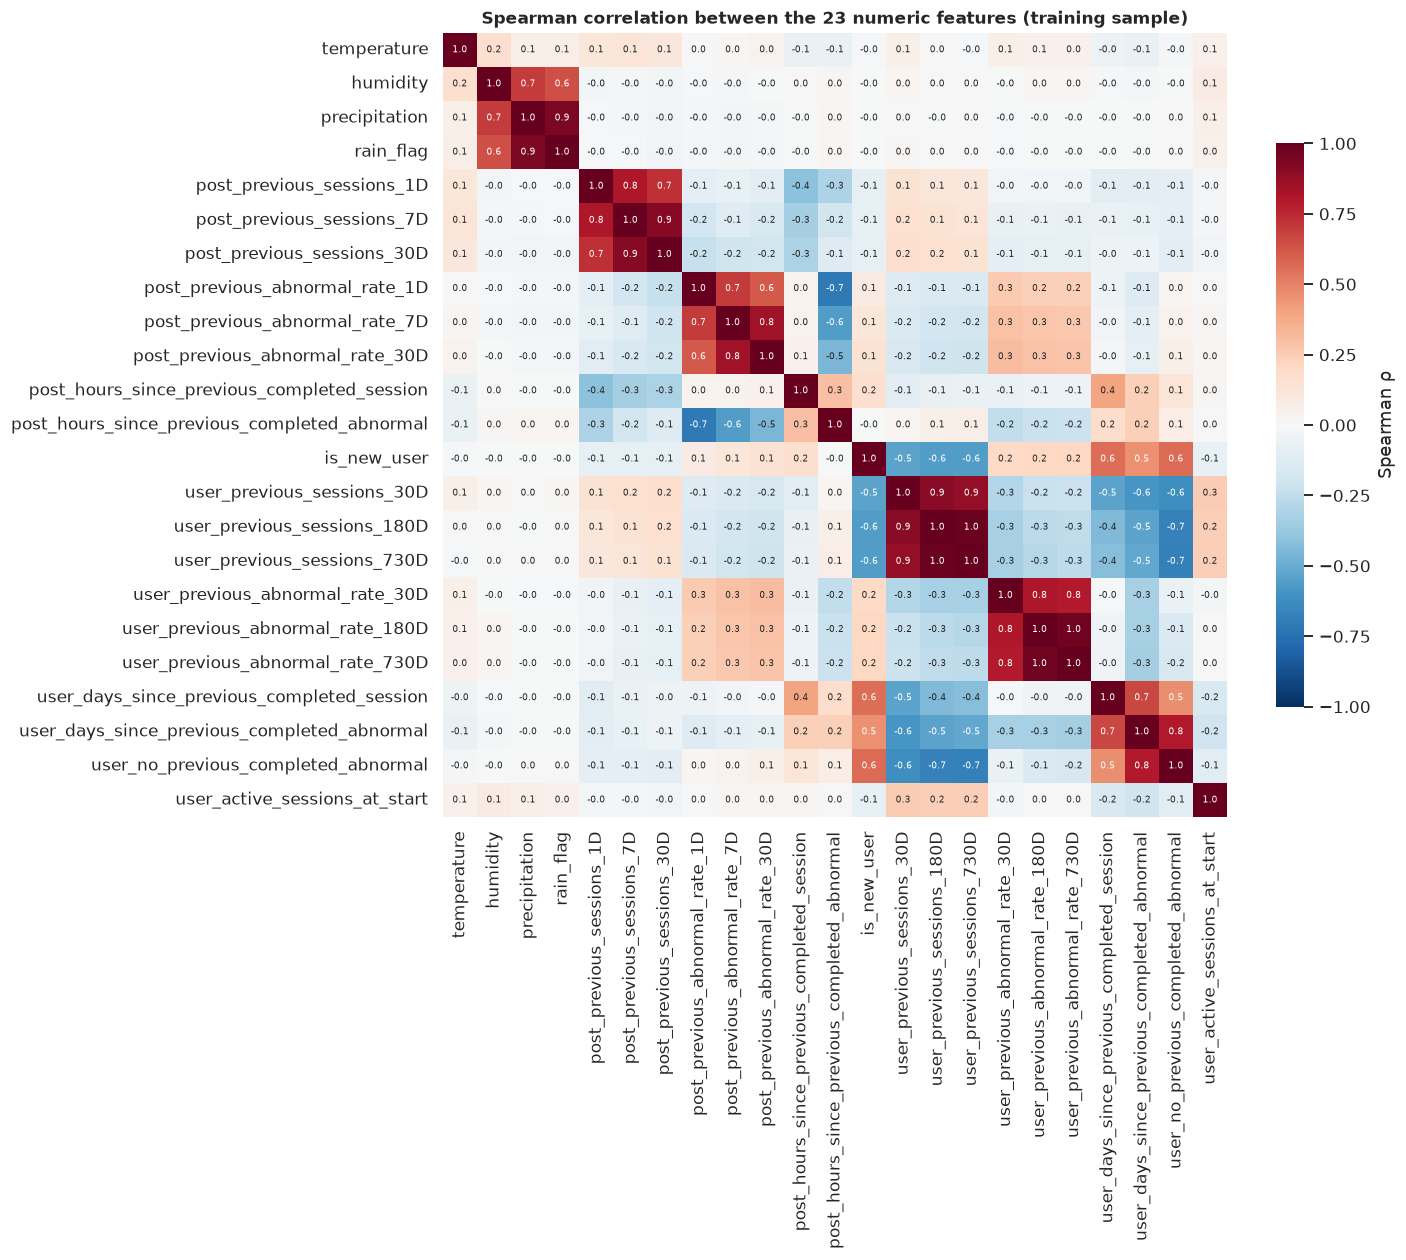

,level_0,level_1,rho
337,user_previous_sessions_180D,user_previous_sessions_730D,0.988
409,user_previous_abnormal_rate_180D,user_previous_abnormal_rate_730D,0.969
49,precipitation,rain_flag,0.939
121,post_previous_sessions_7D,post_previous_sessions_30D,0.909
313,user_previous_sessions_30D,user_previous_sessions_180D,0.905
314,user_previous_sessions_30D,user_previous_sessions_730D,0.876


In [43]:
GROUPS = {
    "calendar": ["hour", "dow"],
    "tariff": ["tariff_period"],
    "location": ["post_id", "location", "district"],
    "weather": ["temperature", "humidity", "precipitation", "rain_flag"],
    "post_history": ["post_previous_sessions_1D", "post_previous_sessions_7D", "post_previous_sessions_30D",
                     "post_previous_abnormal_rate_1D", "post_previous_abnormal_rate_7D", "post_previous_abnormal_rate_30D",
                     "post_hours_since_previous_completed_session", "post_hours_since_previous_completed_abnormal"],
    "user_history": ["is_new_user", "user_previous_sessions_30D", "user_previous_sessions_180D", "user_previous_sessions_730D",
                     "user_previous_abnormal_rate_30D", "user_previous_abnormal_rate_180D", "user_previous_abnormal_rate_730D",
                     "user_days_since_previous_completed_session", "user_days_since_previous_completed_abnormal",
                     "user_no_previous_completed_abnormal"],
    "concurrency": ["user_active_sessions_at_start"],
}
MODEL_FEATURES = [c for cols in GROUPS.values() for c in cols]
CATEGORICAL = ["post_id", "location", "district", "tariff_period"]
BINARY = ["rain_flag", "is_new_user", "user_no_previous_completed_abnormal"]
NUMERIC = [c for c in MODEL_FEATURES if c not in CATEGORICAL + ["hour", "dow"]]
assert len(MODEL_FEATURES) == 29 and len(NUMERIC) == 23

# log1p rule (training data only)
unbounded = [c for c in NUMERIC if c not in BINARY and "rate" not in c and c not in ("temperature", "humidity")]
skew = pd.DataFrame({"train skewness": TRAIN[unbounded].skew(), "after log1p": np.log1p(TRAIN[unbounded]).skew()})
skew["log1p?"] = (skew["train skewness"] > 1) & (skew["after log1p"].abs() <= skew["train skewness"].abs() / 2)
SKEW_LOG = skew.index[skew["log1p?"]].tolist()
display(skew.round(2))

X_diag = SAMPLE[NUMERIC].copy()
X_diag[SKEW_LOG] = np.log1p(X_diag[SKEW_LOG])
X_diag = X_diag.fillna(X_diag.max())            # "never happened" -> far end of the range (as in Section 13)
rho = X_diag.corr(method="spearman")

fig, ax = plt.subplots(figsize=(11.5, 9.5))
sns.heatmap(rho, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, annot=True, fmt=".1f",
            annot_kws={"fontsize": 6}, cbar_kws={"label": "Spearman ρ", "shrink": .7}, ax=ax)
ax.set_title("Spearman correlation between the 23 numeric features (training sample)")
savefig(fig, "12_3_spearman_correlation")

pairs = rho.where(np.triu(np.ones(rho.shape, dtype=bool), 1)).stack().rename("rho").reset_index()
display(pairs[pairs["rho"].abs() >= 0.85].sort_values("rho", key=abs, ascending=False).round(3))

The correlations form blocks that follow the feature groups: the user session counts (30/180/730 days), the user rates, the
post rates, the post session counts, and humidity, precipitation and rain flag. Only a few pairs reach |ρ| ≥ 0.85, and they
are always different windows of the same quantity, for example user sessions over 180 and 730 days. The three post-rate
windows are much less correlated with each other, which fits our idea that they carry different time scales.

Correlations between groups are low, so the groups are fairly separate sources of information. This is useful for the group
ablation in Task 2.

### 12.4 Variance Inflation Factor (VIF)

Pairwise correlations can miss combinations of several variables (a tip from the slides), so we also computed the VIF. It
regresses each feature on all the others, and a VIF above 10 means the feature is almost a linear combination of the others.

In [44]:
Xs = pd.DataFrame(StandardScaler().fit_transform(X_diag), columns=X_diag.columns)


def vif(X):
    out = {}
    for c in X.columns:
        others = X.drop(columns=c)
        r2 = LinearRegression().fit(others, X[c]).score(others, X[c])
        out[c] = 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


vif_all = vif(Xs)
display(vif_all.round(1).to_frame("VIF").T)

,user_previous_sessions_180D,user_previous_sessions_730D,user_previous_abnormal_rate_180D,user_previous_abnormal_rate_730D,user_previous_sessions_30D,user_days_since_previous_completed_abnormal,post_previous_sessions_7D,user_days_since_previous_completed_session,user_no_previous_completed_abnormal,post_previous_sessions_30D,post_previous_abnormal_rate_7D,user_previous_abnormal_rate_30D,is_new_user,post_previous_abnormal_rate_1D,post_previous_abnormal_rate_30D,post_previous_sessions_1D,rain_flag,precipitation,post_hours_since_previous_completed_abnormal,humidity,post_hours_since_previous_completed_session,user_active_sessions_at_start,temperature
VIF,65.4,50.9,28.3,26.4,10.8,7.5,7.5,6.4,5.8,5.7,5.4,4.8,4.7,3.6,3.3,3.0,2.1,2.0,2.0,1.9,1.5,1.3,1.1


Only a handful of features have a VIF above 10, and they are all user-history windows (the 180- and 730-day counts and rates).
The file covers only two years and most accounts are short-lived, so the 180-day and 730-day windows contain almost the same
sessions. Post history, weather and calendar have low VIFs.

### 12.5 What do we do with the redundancy?

The slides (*How to handle highly correlated pairs*) suggest different answers for different models. Tree models handle
correlated features without losing performance, so they keep all 29 features. Regularised linear models (L1/L2) also keep all
features, because the penalty takes care of the redundancy. For plain linear or distance models (for example k-NN) we built a
reduced set: we go through the features from the best to the worst univariate AUC and keep a feature only if its |ρ| with
every feature already kept is below 0.90. We fixed this threshold in advance.

In [45]:
auc_sample = pd.Series({c: auc(SAMPLE[TARGET], X_diag[c]) for c in NUMERIC}).sort_values(ascending=False)
kept, dropped = [], []
for c in auc_sample.index:
    clash = [k for k in kept if abs(rho.loc[c, k]) >= 0.90]
    if clash:
        dropped.append((c, round(auc_sample[c], 3), f"|ρ| = {abs(rho.loc[c, clash[0]]):.2f} with {clash[0]}"))
    else:
        kept.append(c)
LINEAR_REDUCED_NUMERIC = kept
display(pd.DataFrame(dropped, columns=["dropped from the reduced set", "AUC", "reason"]))
print(f"Reduced numeric set: {len(kept)} of {len(NUMERIC)} | maximum VIF {vif_all.max():.1f} -> {vif(Xs[kept]).max():.1f}")

,dropped from the reduced set,AUC,reason
0,user_previous_abnormal_rate_730D,0.687,|ρ| = 0.97 with user_previous_abnormal_rate_180D
1,user_previous_sessions_180D,0.554,|ρ| = 0.99 with user_previous_sessions_730D
2,precipitation,0.508,|ρ| = 0.94 with rain_flag
3,post_previous_sessions_7D,0.505,|ρ| = 0.91 with post_previous_sessions_30D


Reduced numeric set: 19 of 23 | maximum VIF 65.4 -> 8.6


The rule drops four features: one long user window of the rate and one of the counts, `precipitation` (in favour of
`rain_flag`) and one post-count window. In each pair both features have almost the same AUC, so it hardly matters which one
we keep, and the maximum VIF falls below 10. The downside is that dropping `precipitation` loses the amount of rain, but its
effect was weak anyway (Section 9.3).

### 12.6 PCA and discretisation: considered, not adopted

We also tried PCA, which replaces the features with a smaller set of components that keep most of the variance. Following the
slides, we aimed for about 90% of the variance.

Components needed for 90% of the variance: 11 of 23 | first component: 22.8%
Univariate AUC of the first five components: {'PC1': 0.51, 'PC2': 0.8, 'PC3': 0.53, 'PC4': 0.5, 'PC5': 0.59}


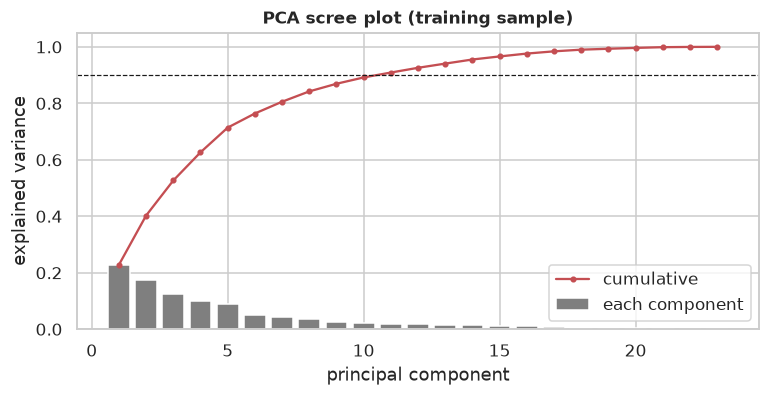

In [46]:
pca = PCA(random_state=SEED).fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.searchsorted(cum, 0.90) + 1)
components = pca.transform(Xs)
print(f"Components needed for 90% of the variance: {n90} of {Xs.shape[1]} | first component: {pca.explained_variance_ratio_[0]:.1%}")
print("Univariate AUC of the first five components:",
      {f"PC{i + 1}": round(auc(SAMPLE[TARGET], components[:, i]), 2) for i in range(5)})

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(1, len(cum) + 1), pca.explained_variance_ratio_, color=C_GREY, label="each component")
ax.plot(range(1, len(cum) + 1), cum, "o-", color=C_ABN, ms=3, label="cumulative")
ax.axhline(.9, color="k", ls="--", lw=.8)
ax.set_xlabel("principal component")
ax.set_ylabel("explained variance")
ax.legend()
ax.set_title("PCA scree plot (training sample)")
savefig(fig, "12_6_pca")

About half of the components are needed to reach 90% of the variance, so PCA compresses little. The first component (the one
with the most variance) is mostly about how active the user is and barely separates the classes (AUC ≈ 0.51), while the second
component, about failure rates, separates them well. This was a useful lesson for us: the direction with the most variance is
not necessarily the most useful one for prediction. We decided not to use PCA. The compression is small, the components would
mix post and user information (which would make the group ablation and the privacy discussion impossible), and tree models do
not need it.

Discretisation (equal-width, equal-frequency, domain-based) was only used to explore the data, in the deciles of Section 9.4
and the weather bands of Section 9.3. We do not apply it to the model inputs. Trees discretise on the fly, as the slides
mention, and for linear models binning would throw away the fine ordering that carries the signal (the decile curves are
smooth). The log transformation is a better choice for them.

As for feature selection, the univariate AUC ranking of Section 9.4 is our *filter method*. We do not select features
automatically from it, because filters ignore interactions. In Task 2, the feature-group ablation will decide which groups to
keep.

### 12.7 Final list: every original column accounted for

To make sure we did not forget anything, we list what happened to every original column.

In [47]:
abnormal_count_cols = [w.format("abnormal") for w in windows]
DROP_REASON = {
    "row_id": "technical id (link to the original file)",
    "user_id": "key field: 56k values, most test accounts unseen in train (Section 11)",
    "order_time": "unclear availability (Section 8.2)",
    "start_time": "converted into hour/dow; defines the split",
    "end_time": "after the session (Section 8); used only for the purge and checks",
    "payment_time": "after the session (Section 8)",
    "energy_kwh": "after the session (Section 8)", "electricity_cost": "after the session (Section 8)",
    "service_charge": "after the session (Section 8)", "amount": "after the session (Section 8)", "actual_payment": "after the session (Section 8)",
    "end_cause": "outcome: only used to build the target (Section 5)",
    "electricity_price": "fixed by tariff_period (Section 4.3)",
    "post_no_previous_completed_session": "always 0 in train/val/test (Section 12.2)",
    "post_no_previous_completed_abnormal": "always 0 in train/val/test (Section 12.2)",
    "user_no_previous_completed_session": "same as is_new_user (Section 12.2)",
    **{c: "exact function of sessions and rate (Section 12.2)" for c in abnormal_count_cols},
}
original = [RENAME.get(c, c) for c in raw.columns] + ["row_id"]
disposition = pd.DataFrame(
    [(c, "keep", next(g for g, cols in GROUPS.items() if c in cols), "") if c in MODEL_FEATURES
     else (c, "drop", "", DROP_REASON[c]) for c in original]
    + [(c, "keep (new)", next(g for g, cols in GROUPS.items() if c in cols), "Section 12.1") for c in ["hour", "dow", "rain_flag"]],
    columns=["column", "decision", "group", "reason"])
assert set(MODEL_FEATURES) <= set(disposition["column"])
display(disposition["decision"].value_counts().to_frame("columns"))
display(disposition[disposition["decision"] == "drop"])
print("Features per group:", {g: len(c) for g, c in GROUPS.items()}, "| total:", len(MODEL_FEATURES))

,columns
decision,
keep,26
drop,22
keep (new),3


,column,decision,group,reason
0,user_id,drop,,"key field: 56k values, most test accounts unse..."
4,order_time,drop,,unclear availability (Section 8.2)
5,energy_kwh,drop,,after the session (Section 8)
6,electricity_cost,drop,,after the session (Section 8)
7,service_charge,drop,,after the session (Section 8)
8,amount,drop,,after the session (Section 8)
9,actual_payment,drop,,after the session (Section 8)
10,start_time,drop,,converted into hour/dow; defines the split
11,end_time,drop,,after the session (Section 8); used only for t...
12,payment_time,drop,,after the session (Section 8)


Features per group: {'calendar': 2, 'tariff': 1, 'location': 3, 'weather': 4, 'post_history': 8, 'user_history': 10, 'concurrency': 1} | total: 29


In the end we keep 29 features in 7 groups: calendar (2), tariff (1), location (3), weather (4), post history (8), user history
(10) and concurrency (1). These groups are the units of the feature-group ablation that the project asks for in Task 2.

In [48]:
log_decision("12", "New variables", "Add hour, dow (circular) and rain_flag; no month/year/time index.",
             "Calendar is the only start-time information in the timestamp; rain is zero-inflated.")
log_decision("12", "Removed columns", "Drop electricity_price, 6 abnormal counts, 2 post no-history flags, "
             "user_no_previous_completed_session; user_id not a feature.",
             "Exact functions / no variability / ~identical indicator / key field (Section 12.2).")
log_decision("12", "Redundancy", "Trees and regularised linear models: all 29 features. Plain linear/distance models: "
             "reduced set (|ρ| < 0.90).", "VIF > 10 only for long user windows; max VIF falls below 10 in the reduced set.")
log_decision("12", "PCA / discretisation", "Not adopted.",
             "PCA needs about half the components for 90% variance; top component has AUC ~0.51. Bins lose the ordering.")

---
## 13. Learned operations (fitted on the training period only)

The brief asks that *any preparation operation that learns information from the data* be documented separately. We fit these
operations on `TRAIN` only and then apply them unchanged to validation and test, following the slide *Prevent data leakage*
(always split first and then scale).

The right preparation depends on the model, so we prepare two *views* of the data. The tree view keeps the raw values, the
`NaN` and the categories as codes, and learns nothing else. The linear / distance view applies `log1p` to the skewed columns,
then fills the structural `NaN` with the training maximum and standardises (z-score). Hour and day of week are encoded as sine
and cosine, and `post_id` and `tariff_period` are one-hot encoded with `handle_unknown="ignore"` (the slides note that
*OneHotEncoder respects the train/validation/test workflow*). We leave `location` and `district` out of this view, because
they are exact combinations of the `post_id` columns (nested hierarchy, Section 4.3).

Everything is inside a scikit-learn `Pipeline`, so in Task 2 it will be re-fitted automatically inside each training fold.

In [49]:
class FillWithTrainMax(BaseEstimator, TransformerMixin):
    """Replace a structural NaN ('the event never happened') with the column maximum learned in fit()."""

    def fit(self, X, y=None):
        self.fill_ = np.nanmax(np.asarray(X, dtype=float), axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        rows, cols = np.where(np.isnan(X))
        X[rows, cols] = self.fill_[cols]
        return X


def cyclical(X):
    """Sine/cosine encoding: hour (period 24) and day of week (period 7). Nothing is learned."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.sin(2 * np.pi * X[:, 0] / 24), np.cos(2 * np.pi * X[:, 0] / 24),
                            np.sin(2 * np.pi * X[:, 1] / 7), np.cos(2 * np.pi * X[:, 1] / 7)])


other_numeric = [c for c in NUMERIC if c not in SKEW_LOG + BINARY]
linear_view = ColumnTransformer([
    ("log_fill_scale", Pipeline([("log1p", FunctionTransformer(np.log1p)), ("fill", FillWithTrainMax()),
                                 ("scale", StandardScaler())]), SKEW_LOG),
    ("fill_scale", Pipeline([("fill", FillWithTrainMax()), ("scale", StandardScaler())]), other_numeric),
    ("binary", "passthrough", BINARY),
    ("cyclical", FunctionTransformer(cyclical), ["hour", "dow"]),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["post_id", "tariff_period"]),
])

linear_view.fit(TRAIN)                                  # fitted on the training period only
X_train, X_val, X_test = (linear_view.transform(part) for part in (TRAIN, VAL, TEST))
print(f"Linear view: {X_train.shape[1]} columns | NaN left: train {np.isnan(X_train).sum()}, "
      f"validation {np.isnan(X_val).sum()}, test {np.isnan(X_test).sum()}")
print(f"Smallest post in train: {TRAIN['post_id'].value_counts().min()} sessions -> no rare categories to group")

Linear view: 126 columns | NaN left: train 0, validation 0, test 0
Smallest post in train: 244 sessions -> no rare categories to group


In [50]:
# For comparison: what if we had (wrongly) fitted on all periods, including validation and test?
linear_all = clone(linear_view).fit(df[df["split"].isin(["train", "val", "test"])])


def learned(ct, block, step, attribute, column):
    columns = {name: cols for name, _, cols in ct.transformers_}[block]
    return getattr(ct.named_transformers_[block].named_steps[step], attribute)[columns.index(column)]


examples = [
    ("NaN fill (days)", "log_fill_scale", "fill", "fill_", "user_days_since_previous_completed_abnormal", np.expm1),
    ("scaler mean", "fill_scale", "scale", "mean_", "temperature", lambda v: v),
    ("scaler mean", "fill_scale", "scale", "mean_", "post_previous_abnormal_rate_7D", lambda v: v),
    ("scaler mean (after log)", "log_fill_scale", "scale", "mean_", "user_previous_sessions_30D", lambda v: v),
]
display(pd.DataFrame([{"learned value": op, "column": col,
                       "fitted on TRAIN (correct)": back(learned(linear_view, b, s, a, col)),
                       "fitted on all periods (leakage)": back(learned(linear_all, b, s, a, col))}
                      for op, b, s, a, col, back in examples]).round(3))

,learned value,column,fitted on TRAIN (correct),fitted on all periods (leakage)
0,NaN fill (days),user_days_since_previous_completed_abnormal,543.420,702.308
1,scaler mean,temperature,19.552,20.027
2,scaler mean,post_previous_abnormal_rate_7D,0.177,0.181
3,scaler mean (after log),user_previous_sessions_30D,2.278,2.213


The linear view has no `NaN` in any period, and no category needs grouping, since every post has hundreds of training
sessions. To see why fitting only on `TRAIN` matters, we also fitted the same pipeline on all periods, and the learned values
change. For example, the fill value for "days since the user's last failure" would move from 543 to 702 days, and the mean
temperature from 19.55 °C to 20.03 °C. The differences are small, but they are information from the validation and test
periods, which the model should not see.

### 13.1 Ledger of learned operations

In [51]:
LEDGER = pd.DataFrame([
    ("One-hot encoding", "post_id, tariff_period (linear view)", "list of categories", "TRAIN", "unknown category -> all zeros"),
    ("Category codes", "post_id, location, district, tariff_period (tree view)", "list of categories", "TRAIN", "unknown -> missing"),
    ("Structural NaN fill", "4 'time since' columns (linear view)", "training maximum", "TRAIN", "flags kept (Section 6)"),
    ("Standardisation (z-score)", "non-binary numeric columns (linear view)", "mean and standard deviation", "TRAIN", "only for scale-sensitive models"),
    ("Log transform rule", f"{len(SKEW_LOG)} skewed columns", "which columns: training skewness", "TRAIN", "the log itself learns nothing"),
    ("Reduced feature set", f"{len(LINEAR_REDUCED_NUMERIC)} numeric columns", "Spearman ρ and univariate AUC", "TRAIN sample", "plain linear / distance models only"),
    ("Class-imbalance treatment", "training rows", "class weights or resampling", "each TRAIN fold (Task 2)", "never on validation/test"),
    ("Feature-group selection", "7 groups", "group ablation", "TRAIN folds (Task 2)", "not done in Task 1"),
    ("Outlier thresholds / capping", "—", "—", "not used", "log transform instead (Section 10)"),
    ("PCA", "—", "—", "not used", "Section 12.6"),
    ("Rare-category grouping", "—", "—", "not needed", "smallest post has hundreds of training sessions"),
], columns=["learned operation", "applies to", "what is learned", "fitted on", "note"])
display(LEDGER)
log_decision("13", "Learned operations", "Fit encoders, NaN fill and scaler on TRAIN only, inside a Pipeline.",
             "Fitting on all periods changes the learned values (table above).")

,learned operation,applies to,what is learned,fitted on,note
0,One-hot encoding,"post_id, tariff_period (linear view)",list of categories,TRAIN,unknown category -> all zeros
1,Category codes,"post_id, location, district, tariff_period (tr...",list of categories,TRAIN,unknown -> missing
2,Structural NaN fill,4 'time since' columns (linear view),training maximum,TRAIN,flags kept (Section 6)
3,Standardisation (z-score),non-binary numeric columns (linear view),mean and standard deviation,TRAIN,only for scale-sensitive models
4,Log transform rule,8 skewed columns,which columns: training skewness,TRAIN,the log itself learns nothing
5,Reduced feature set,19 numeric columns,Spearman ρ and univariate AUC,TRAIN sample,plain linear / distance models only
6,Class-imbalance treatment,training rows,class weights or resampling,each TRAIN fold (Task 2),never on validation/test
7,Feature-group selection,7 groups,group ablation,TRAIN folds (Task 2),not done in Task 1
8,Outlier thresholds / capping,—,—,not used,log transform instead (Section 10)
9,PCA,—,—,not used,Section 12.6


### 13.2 Class imbalance

There is about 1 abnormal session for every 4.4 normal ones (17.8% in train, 21.1% in validation, 17.6% in test). The slides
warn that with unbalanced classes *the classifier can show a high accuracy with little or no usefulness*.

We decided not to resample the prepared data. If Task 2 uses undersampling, oversampling, SMOTE or class weights, it will do
so only inside the training folds, so validation and test keep their real class distribution and the results measured on them
are realistic. SMOTE in particular needs care here: interpolating between sessions would create impossible combinations (half
a flag, a count between two windows, a mix of two posts) and ignores the time order. For the same reason we will not rely on
accuracy, but use precision, recall, PR-AUC (compared with the base rate) and a confusion matrix, and choose the decision
threshold on validation.

In [52]:
log_decision("13", "Class imbalance", "No resampling of the prepared data; any resampling/weights only inside training folds (Task 2).",
             "Imbalance ~1:4.4 and it changes between periods (17.8% / 21.1% / 17.6%).")

---
## 14. Saved files and integrity checks

The prepared file keeps the raw (untransformed) features, the target, the timestamps needed for the split and the purge, and
the split label. We do not save transformed data, because the transformations must be re-fitted inside each model pipeline
(Section 13). At the end we run a few checks to make sure nothing leaked into the saved file.

In [53]:
BORDERLINE = ["order_lag_min"]          # kept only for a possible sensitivity test in Task 2
POST_HOC = ["energy_kwh", "electricity_cost", "service_charge", "amount", "actual_payment",
            "duration_h", "payment_lag_h", "end_time", "payment_time", "end_cause", "order_time"]
prepared = df[["row_id", "start_time", "end_time", "split"] + MODEL_FEATURES + BORDERLINE + [TARGET]]
prepared.to_csv(OUT_DIR / "task1_prepared.csv.gz", index=False, compression="gzip")
pd.DataFrame(DECISIONS).to_csv(OUT_DIR / "decision_log.csv", index=False)
LEDGER.to_csv(OUT_DIR / "learned_operations_ledger.csv", index=False)
(OUT_DIR / "feature_groups.json").write_text(json.dumps(
    {"groups": GROUPS, "categorical": CATEGORICAL, "binary": BINARY, "log1p": SKEW_LOG,
     "linear_reduced_numeric": LINEAR_REDUCED_NUMERIC, "borderline": BORDERLINE}, indent=2))

checks = {
    "no after-session or outcome column among the features": not set(MODEL_FEATURES) & set(POST_HOC),
    "user_id is not a feature": "user_id" not in MODEL_FEATURES,
    "train < validation < test in time":
        TRAIN["start_time"].max() < VAL["start_time"].min() <= VAL["start_time"].max() < TEST["start_time"].min(),
    "every training label is known before the cut-off (purge)": bool((TRAIN["end_time"] < TRAIN_END).all()),
    "no burn-in session in train": bool((TRAIN["start_time"] >= BURN_IN_END).all()),
    "the scaler saw only training rows": linear_view.named_transformers_["fill_scale"].named_steps["scale"].n_samples_seen_ == len(TRAIN),
    "target has no missing values": bool(prepared[TARGET].notna().all()),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), "an integrity check failed"
print("Saved:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))
print("Rows per split:", prepared["split"].value_counts().to_dict())

,passed
no after-session or outcome column among the features,True
user_id is not a feature,True
train < validation < test in time,True
every training label is known before the cut-off (purge),True
no burn-in session in train,True
the scaler saw only training rows,True
target has no missing values,True


Saved: ['decision_log.csv', 'feature_groups.json', 'learned_operations_ledger.csv', 'task1_prepared.csv.gz']
Rows per split: {'train': 271182, 'test': 80081, 'val': 75769, 'burn-in': 14017, 'purged': 28}


---
## 15. Synthesis

#### 1. Most important characteristics and problems
The first problem was that the file has no target column. We built `is_Abnormal` from `end_cause` (the 13 fault causes are
abnormal), and the dataset's own history columns agree with this definition in about 100% of the rows (Section 5.2). With it,
18.58% of the sessions are abnormal, about 1 for every 4.4 normal ones.

The biggest risk we found is leakage. Seven columns (energy, money, end and payment times) and `end_cause` describe the result
of the session, and `Order creation time` is stamped after the start in 56% of the sessions (Section 8). The records
themselves are in good shape: no duplicates or impossible records, only structural missing values, and hidden tabs that were
fixed by stripping (Sections 2, 4 and 6).

The data also change over time. Monthly volume goes from 1.4k to 28k sessions, the abnormal share from 13.7% to 26%,
connection faults almost disappear after mid-2020, four posts stop in September 2021, and the history columns are incomplete
in Q1-2020 (Section 7). The main signal is in the posts: failures are concentrated in some of them, and a post that failed
recently tends to fail again. Post history is the strongest signal, user history comes second, and calendar, weather and
tariff add little (Sections 8.1 and 9). Finally, a few fleet accounts have a large share of the sessions, and 61% of the test
sessions come from accounts that never appear in training (Sections 9.5 and 11).

#### 2. Evidence behind the decisions
Every decision in the log below points to the check that supports it. The target is supported by our recount of the history
columns (Section 5.2), and the excluded columns by their univariate AUC of 0.82–0.85, higher than any start-time variable
(Section 8.1). We kept the missing values as "never happened" because they match the no-history flags in 100% of the rows
(Section 6), and the outliers because the extreme cases are real situations (Section 10). The time split follows from the
monthly analysis (Sections 7 and 11), the removed columns from exact functions, no variability or duplicate indicators
(Section 12.2), and fitting on the training period only from the change in the learned values when they are fitted on all
periods (Section 13).

#### 3. Variables kept for modelling
We keep 29 features in 7 groups: calendar (2), tariff (1), location (3), weather (4), post history (8), user history (10) and
concurrency (1). Plain linear or distance models get a reduced set of 19 numeric features (Section 12.5).

#### 4. Open limitations and assumptions
* We treat weather as a forecast. If it was measured during the day, it contains information from after the start.
* Session durations stop at 24 h, and we could not explain the timing of the order and payment fields.
* Our explanations for the changes over time (COVID-19, Spring Festival, early connection problems) are hypotheses.
* No post in the test period is new, so we cannot test how the model handles a new post.
* Fleet accounts dominate the user counts.

#### 5. What this means for Task 2
We will use the chronological split with the purge, tune with expanding-window folds inside the training period, and use the
test period only once. Accuracy is not enough here, so we will report precision, recall, PR-AUC (compared with each period's
base rate), ROC-AUC and the confusion matrix, and check the thresholds and calibration, because the base rate changes between
periods. Class imbalance will be handled with the threshold, class weights or resampling, only inside the training folds, and
we need to be careful with SMOTE.

For the models, tree ensembles seem a good fit for this data (skewed columns, `NaN`, correlated windows) and will use the tree
view, while a regularised logistic regression is a simple baseline for the linear view. The feature-group ablation will compare
context only, context + post history, context + user history and everything, with and without `post_id`. We will report new
users separately and discuss the privacy cost of user history.

In [54]:
display(pd.DataFrame(DECISIONS))

,section,topic,decision,evidence
0,4,Text and dates,"Strip spaces/tabs, parse the four timestamps, ...","TAB on 100% of order/payment times and on 18,3..."
1,5,Target,is_Abnormal = 1 when end_cause is one of the 1...,Our counts reproduce the dataset's own previou...
2,5,Label noise,"Keep the 9,058 zero-energy sessions labelled n...",Plausible user cancellations; filtering on ene...
3,6,Missing values,"No deletion, no mean/median or model imputatio...",NaN equals the no-history flag in 100% of rows...
4,7,Burn-in,Do not use sessions before 2020-04-01 for mode...,History columns incomplete at file start (new ...
5,7,Time split,"Chronological split, no random split.","Volume, abnormal share (13.7%-26.3%) and failu..."
6,8,Leakers,"Exclude energy, the four money columns, end_ti...",Only known after the session; univariate AUC 0...
7,8,Order creation time,Exclude from the predictors.,Stamped after the start in 57.2% of training s...
8,10,Outliers,Keep all observations. Trees: no change. Linea...,"Extremes are valid: idle posts (~2x abnormal),..."
9,11,Split,"Train 2020-04-01..2021-06-30 (purged), validat...",Changes over time (Section 7); 28 training ses...
